# Dashboard de Anomalias - EDA

Exploracao inicial do processo de gravacao de setupbox, com foco em encontrar anomalias sistematicas antes da construcao do dashboard.

In [195]:
#Imports

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2",
    font_scale=1.05,
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

STATUS_PALETTE = {
    "PASS": "#2E7D32",
    "FAIL": "#C62828",
    "REWORK": "#F9A825",
    "SCRAP": "#6A1B9A",
}

In [196]:
DATA_PATH = Path('../Data/recording_test_setupbox.xlsx')

dataset = pd.read_excel(DATA_PATH, sheet_name='recordings')
line_stops = pd.read_excel(DATA_PATH, sheet_name='line_stops')
data_dictionary = pd.read_excel(DATA_PATH, sheet_name='data_dictionary')

In [197]:
dataset.head()

,timestamp,date,time,shift,line,station,jig_id,operator,model,sku,wifi_band,has_bluetooth,has_cable,firmware_version,serial_number,mac_address,api_key,attempt,fw_download_ok,fw_download_cycle_s,fw_download_md5,bootloader_ok,bootloader_cycle_s,bootloader_md5,kernel_ok,kernel_cycle_s,kernel_md5,rootfs_ok,rootfs_cycle_s,rootfs_md5,secure_boot_ok,secure_boot_cycle_s,secure_boot_md5,mac_write_ok,mac_write_cycle_s,mac_write_md5,wifi_cal_ok,wifi_cal_cycle_s,wifi_cal_md5,bluetooth_ok,bluetooth_cycle_s,bluetooth_md5,cable_scan_ok,cable_scan_cycle_s,cable_scan_md5,hdmi_edid_ok,hdmi_edid_cycle_s,hdmi_edid_md5,dvb_tuner_ok,dvb_tuner_cycle_s,dvb_tuner_md5,drm_keys_ok,drm_keys_cycle_s,drm_keys_md5,final_check_ok,final_check_cycle_s,final_check_md5,cable_channels_found,total_cycle_s,result,failed_step,error_code,disposition
0,2022-09-12 06:00:06,2022-09-12,06:00:06,A,L2,L2-ST1,JIG-L2-ST1-2,OP-L2-A2,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912083468,AC:5A:14:FB:E9:2B,RKEY-05B595FC92,1,True,12.80,8f9c832283bc6fa931da2c68e66da06c,True,7.60,e5e889166685aae9ea816fbd4b52e319,True,27.70,d0af4a614682e7bee95182bec5477298,True,38.40,630aee2328d502b6a8342c49610f3438,True,6.60,52bce2e22e945dc897f72eb4951871d5,True,3.80,f96ef125d029674df8000b867fa45c1a,True,33.30,8dd4ec9223c6b2684350790a6962dd38,1.00,15.60,27b5b9be5427a5a3b0b35e96df4330bd,1.00,35.10,21b28496b3d5e5389f4837847c2babe7,True,7.70,bebe4eee67d261bf493caeabd88b676f,True,18.30,92434477b026a09bf82617fda8edfe1c,True,10.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.20,7d761ebaf0435d3a4145fba0f02e32df,124.00,222.20,PASS,NaN,NaN,PASS
1,2022-09-12 06:00:07,2022-09-12,06:00:07,A,L1,L1-ST1,JIG-L1-ST1-1,OP-L1-A2,STB-100,LG-STB-100-2401,2.4GHz,False,False,v4.1.2,SN100220912073344,AC:5A:14:67:01:4C,RKEY-1AA670E63C,1,True,9.90,0d9346909082cbf9be11d3b7d4f2dc6c,True,8.80,f4d35c18a8c9a087421007f6b127780b,True,23.90,775e499985711c57608ac7ca210cc7e6,True,41.50,29329042173e587145f6e319f5481a31,True,6.00,19711710751177200ed1e3623ea6cb87,True,3.70,51bdcaad241d88e4c20069e85544c526,True,26.80,7c5ae2c9ee045a955dbf956a22b20165,NaN,NaN,NaN,NaN,NaN,NaN,True,7.20,1d45998b38268cadb47559c03e2dd0ef,True,15.80,91f9285bc19f6bf39fb8e01da1dc948e,True,8.90,a41d8f6bc155e6fbc73a07596c1556a2,True,4.50,0b308b6e810da8624459a91eb154c4e7,NaN,157.00,PASS,NaN,NaN,PASS
2,2022-09-12 06:00:41,2022-09-12,06:00:41,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A1,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912073087,AC:5A:14:DB:76:1E,RKEY-05B595FC92,1,True,11.90,8f9c832283bc6fa931da2c68e66da06c,True,8.20,e5e889166685aae9ea816fbd4b52e319,True,25.00,d0af4a614682e7bee95182bec5477298,True,39.30,630aee2328d502b6a8342c49610f3438,True,6.50,52bce2e22e945dc897f72eb4951871d5,True,4.10,f96ef125d029674df8000b867fa45c1a,True,27.20,8dd4ec9223c6b2684350790a6962dd38,1.00,15.10,27b5b9be5427a5a3b0b35e96df4330bd,1.00,34.70,21b28496b3d5e5389f4837847c2babe7,True,8.40,bebe4eee67d261bf493caeabd88b676f,True,18.10,92434477b026a09bf82617fda8edfe1c,True,8.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.00,7d761ebaf0435d3a4145fba0f02e32df,126.00,211.60,PASS,NaN,NaN,PASS
3,2022-09-12 06:01:00,2022-09-12,06:01:00,A,L3,L3-ST2,JIG-L3-ST2-1,OP-L3-A2,STB-200,LG-STB-200-5C02,5GHz,False,True,v4.1.2,SN200220912078449,AC:5A:14:69:DD:B6,RKEY-1999061AD6,1,True,13.00,6050b8067d8bc1b16e6be2a078bc37ae,True,7.80,8f5d6101ddfaa62ae36d609073bc6129,True,24.20,0ef0c57946f8050913763c42d10ef2d9,True,38.10,c0679c6229a1372eab671da68f8dca30,True,5.60,3fb781d5d811a31931c68de2cd0e503c,True,3.80,431535d30c8c835c83975a7504fd5fcd,True,32.80,2e2714ad8c8808b8586f6505c5a23169,NaN,NaN,NaN,1.00,31.70,9370d8768535fa77c959078d8ccd7379,True,8.10,f89660499ce56b81f0a4ff767fe2637c,True,16.00,858037ddc1424fcb24cb85aa5028c778,True,9.70,d5efb1054f9129510bb384635bcef647,True,5.10,ff6e7d9b01c0fc8635391957a783a2a9,177.00,195.90,PASS,NaN,NaN,PASS
4,2022-09-12 06:01:14,2022-09-12,06:01:14,A,L4,L4-ST1,JIG-L4-ST1-1,OP-L4-A1,STB-400,LG-STB-400-5BC4,5GHz,True,True,v4.1.2,SN400220912079140,AC:5A:14:65:6C:6D,RKEY-2742E4DF18,1,T

In [198]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 17844 entries, 0 to 17843
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             17844 non-null  str    
 1   date                  17844 non-null  str    
 2   time                  17844 non-null  str    
 3   shift                 17844 non-null  str    
 4   line                  17844 non-null  str    
 5   station               17844 non-null  str    
 6   jig_id                17844 non-null  str    
 7   operator              17844 non-null  str    
 8   model                 17844 non-null  str    
 9   sku                   17844 non-null  str    
 10  wifi_band             17844 non-null  str    
 11  has_bluetooth         17844 non-null  bool   
 12  has_cable             17844 non-null  bool   
 13  firmware_version      17844 non-null  str    
 14  serial_number         17844 non-null  str    
 15  mac_address           17844 no

Estatística Descritiva e Limpeza

In [199]:
dataset.describe()

,attempt,fw_download_cycle_s,bootloader_cycle_s,kernel_cycle_s,rootfs_cycle_s,secure_boot_cycle_s,mac_write_cycle_s,wifi_cal_cycle_s,bluetooth_ok,bluetooth_cycle_s,cable_scan_ok,cable_scan_cycle_s,hdmi_edid_cycle_s,dvb_tuner_cycle_s,drm_keys_cycle_s,final_check_cycle_s,cable_channels_found,total_cycle_s
count,"17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","7,026.00","7,026.00","12,263.00","12,263.00","17,844.00","17,844.00","17,844.00","17,844.00","12,263.00","17,844.00"
mean,1.10,12.16,8.08,26.44,40.40,6.07,4.04,30.97,0.99,16.19,0.99,35.32,8.11,18.26,10.16,5.09,151.85,200.42
std,0.30,2.91,1.68,6.68,8.50,1.28,0.82,8.03,0.08,3.53,0.09,7.17,1.98,4.44,2.62,1.41,21.74,27.31
min,1.00,8.00,5.30,16.80,27.70,4.00,2.70,20.80,0.00,11.40,0.00,24.80,5.10,12.40,6.50,3.40,0.00,148.60
25%,1.00,11.30,7.60,24.60,37.80,5.70,3.80,28.40,1.00,15.10,1.00,33.00,7.60,17.00,9.50,4.70,136.00,172.00
50%,1.00,12.00,8.00,26.00,40.00,6.00,4.00,30.10,1.00,16.00,1.00,35.00,8.00,18.00,10.00,5.00,153.00,204.70
75%,1.00,12.60,8.40,27.40,42.20,6.30,4.20,31.80,1.00,16.90,1.00,36.90,8.40,19.00,10.50,5.30,169.00,217.30
max,2.00,83.10,49.80,164.70,262.30,34.70,23.30,193.80,1.00,102.40,1.00,225.90,53.80,124.40,66.10,34.10,185.00,444.30


In [200]:
#Verificando se existem valores ausentes

dataset.isnull().sum()

timestamp                   0
date                        0
time                        0
shift                       0
line                        0
station                     0
jig_id                      0
operator                    0
model                       0
sku                         0
wifi_band                   0
has_bluetooth               0
has_cable                   0
firmware_version            0
serial_number               0
mac_address                 0
api_key                     0
attempt                     0
fw_download_ok              0
fw_download_cycle_s         0
fw_download_md5             0
bootloader_ok               0
bootloader_cycle_s          0
bootloader_md5              0
kernel_ok                   0
kernel_cycle_s              0
kernel_md5                  0
rootfs_ok                   0
rootfs_cycle_s              0
rootfs_md5                  0
secure_boot_ok              0
secure_boot_cycle_s         0
secure_boot_md5             0
mac_write_

Os valores ausentes precisam ser interpretados pelo contexto do processo. Campos `bluetooth_*` sao nulos para modelos sem Bluetooth; campos `cable_scan_*` e `cable_channels_found` sao nulos para modelos sem cabo. Ja `failed_step` e `error_code` ficam nulos quando a tentativa passa, portanto esses nulos sao esperados em registros `PASS`.

In [201]:
dataset.select_dtypes(include=['str']).nunique()

timestamp           16965
date                    3
time                15366
shift                   2
line                    4
station                 8
jig_id                 16
operator               16
model                   4
sku                     4
wifi_band               2
firmware_version        2
serial_number       16115
mac_address         16066
api_key                12
fw_download_md5       247
bootloader_md5         66
kernel_md5             91
rootfs_md5            636
secure_boot_md5        82
mac_write_md5          77
wifi_cal_md5          111
bluetooth_md5          45
cable_scan_md5        114
hdmi_edid_md5          89
dvb_tuner_md5          96
drm_keys_md5          703
final_check_md5        89
result                  2
failed_step            13
error_code             11
disposition             3
dtype: int64

Colunas temporais e identificadores unicos (`timestamp`, `serial_number`, `mac_address`) indicam que parte da analise deve ser temporal e parte deve verificar integridade.

Variaveis categoricas uteis para cortes: `shift`, `line`, `station`, `jig_id`, `operator`, `model`, `sku`, `wifi_band`, `firmware_version`, `api_key`, `result` e `disposition`.

Variaveis de processo: `failed_step`, `error_code`, `attempt`, `total_cycle_s` e os tempos por etapa (`*_cycle_s`).

Variaveis de configuracao/checksum: colunas `*_md5`, que ajudam a investigar lotes ou imagens especificas.

# EDA

### Entendendo a concetraçao de falhas

### Distribuição de Pareto

Objetivo: identificar os poucos defeitos que concentram a maior parte das falhas e priorizar o que investigar primeiro.

In [202]:
failures = dataset.loc[dataset["result"].eq("FAIL")].copy()

print(f"Total de tentativas: {len(dataset):,}")
print(f"Total de falhas: {len(failures):,}")
print(f"Taxa de falha: {len(failures) / len(dataset):.2%}")

Total de tentativas: 17,844
Total de falhas: 2,296
Taxa de falha: 12.87%


In [203]:
def build_pareto(df, column):
    pareto = (
        df[column]
        .dropna()
        .value_counts()
        .rename_axis(column)
        .reset_index(name="count")
    )
    pareto["pct"] = pareto["count"] / pareto["count"].sum()
    pareto["cum_pct"] = pareto["pct"].cumsum()
    return pareto


def plot_pareto(df, column, title, ax):
    pareto = build_pareto(df, column)

    sns.barplot(
        data=pareto,
        x=column,
        y="count",
        ax=ax,
        color="#4C78A8",
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de falhas")
    ax.tick_params(axis="x", rotation=45)
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(
        pareto[column],
        pareto["cum_pct"] * 100,
        color="#C62828",
        marker="o",
        linewidth=2,
    )
    ax2.axhline(80, color="#616161", linestyle="--", linewidth=1)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Percentual acumulado")
    ax2.yaxis.set_major_formatter(PercentFormatter())

    return pareto

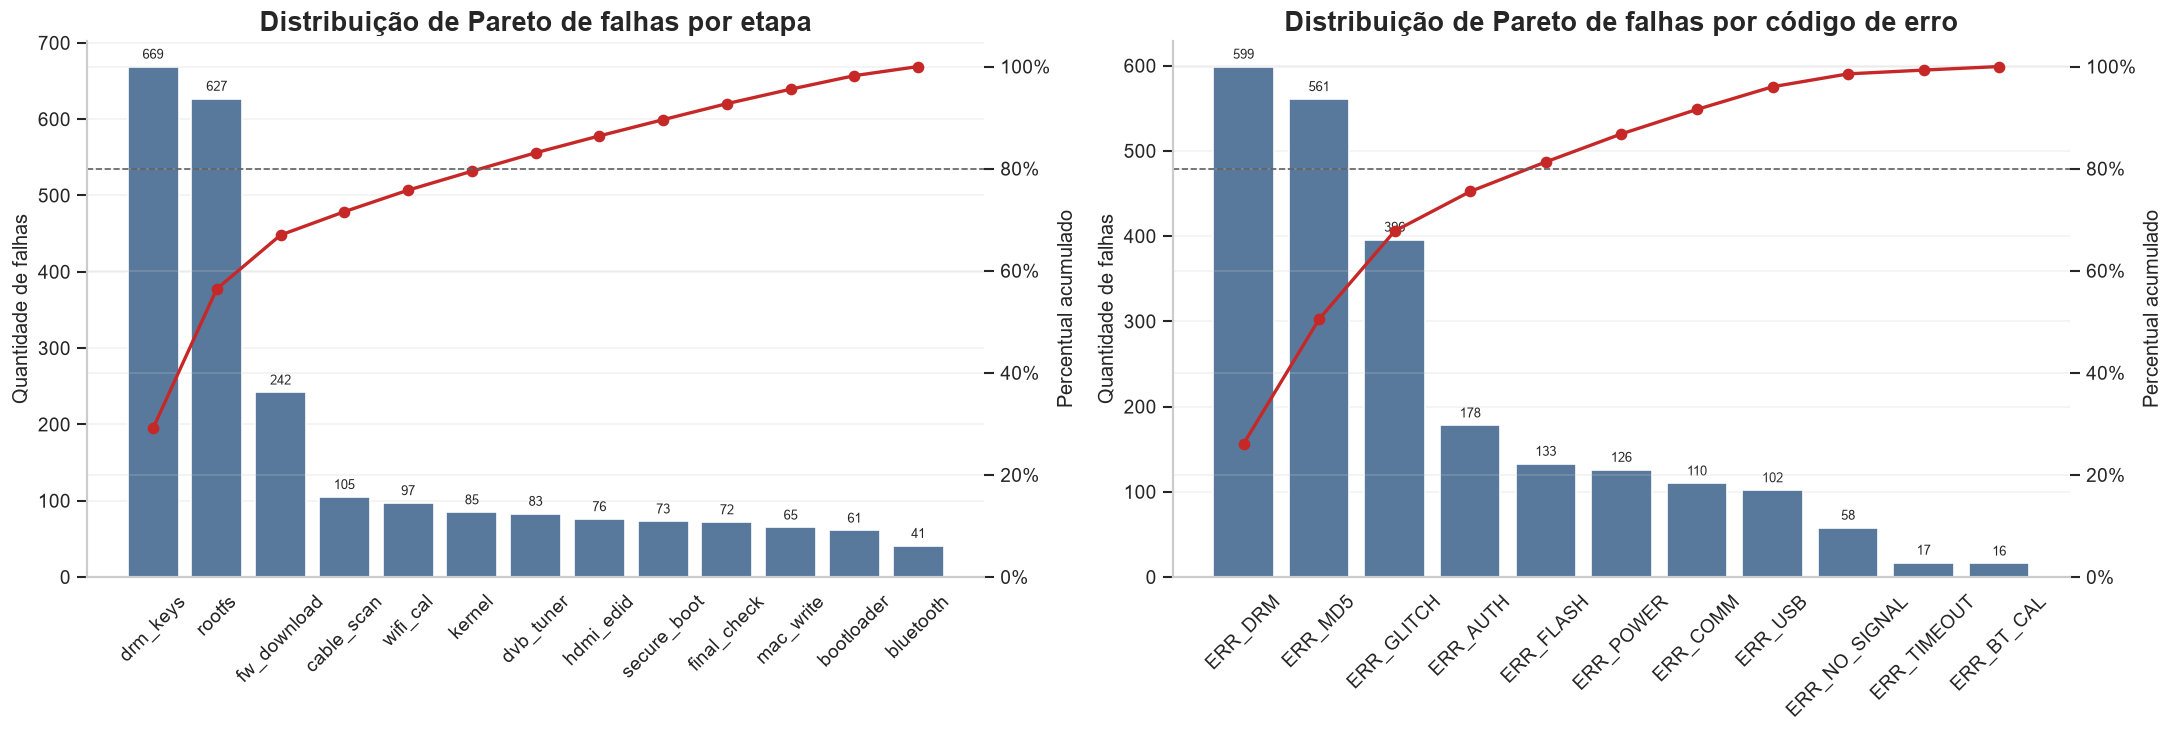

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

pareto_failed_step = plot_pareto(
    failures,
    "failed_step",
    "Distribuição de Pareto de falhas por etapa",
    axes[0],
)

pareto_error_code = plot_pareto(
    failures,
    "error_code",
    "Distribuição de Pareto de falhas por código de erro",
    axes[1],
)

plt.show()

In [205]:
pareto_failed_step_display = pareto_failed_step.copy()
pareto_failed_step_display["pct"] = (pareto_failed_step_display["pct"] * 100).map("{:.2f}%".format)
pareto_failed_step_display["cum_pct"] = (pareto_failed_step_display["cum_pct"] * 100).map("{:.2f}%".format)

pareto_error_code_display = pareto_error_code.copy()
pareto_error_code_display["pct"] = (pareto_error_code_display["pct"] * 100).map("{:.2f}%".format)
pareto_error_code_display["cum_pct"] = (pareto_error_code_display["cum_pct"] * 100).map("{:.2f}%".format)

display(pareto_failed_step_display)
display(pareto_error_code_display)

,failed_step,count,pct,cum_pct
0,drm_keys,669,29.14%,29.14%
1,rootfs,627,27.31%,56.45%
2,fw_download,242,10.54%,66.99%
3,cable_scan,105,4.57%,71.56%
4,wifi_cal,97,4.22%,75.78%
5,kernel,85,3.70%,79.49%
6,dvb_tuner,83,3.61%,83.10%
7,hdmi_edid,76,3.31%,86.41%
8,secure_boot,73,3.18%,89.59%
9,final_check,72,3.14%,92.73%


,error_code,count,pct,cum_pct
0,ERR_DRM,599,26.09%,26.09%
1,ERR_MD5,561,24.43%,50.52%
2,ERR_GLITCH,396,17.25%,67.77%
3,ERR_AUTH,178,7.75%,75.52%
4,ERR_FLASH,133,5.79%,81.32%
5,ERR_POWER,126,5.49%,86.80%
6,ERR_COMM,110,4.79%,91.59%
7,ERR_USB,102,4.44%,96.04%
8,ERR_NO_SIGNAL,58,2.53%,98.56%
9,ERR_TIMEOUT,17,0.74%,99.30%


Cerca de 12,87% das tentativas falharam. Dentro das falhas, `drm_keys` representa 29,14%, `rootfs` 27,31% e `fw_download` 10,54%. Essas tres etapas somam 66,99% das falhas, entao devem ser priorizadas na investigacao.

Por codigo de erro, `ERR_DRM` representa 26,09%, `ERR_MD5` 24,43% e `ERR_GLITCH` 17,25%. Somados, tambem explicam quase dois tercos dos erros. A investigacao deve comecar por `drm_keys/ERR_DRM`, `rootfs/ERR_MD5` e `fw_download/ERR_AUTH`, porque esses grupos concentram a maior parte dos defeitos e sugerem problemas sistematicos.

## Recorte do defeito principal: drm_keys / ERR_DRM

Objetivo - fatiar o defeito principal para responder: onde acontece, quando acontece e qual e o impacto por linha/jig.

In [206]:
analysis_df = dataset.copy()
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"])
analysis_df["is_fail"] = analysis_df["result"].eq("FAIL")

MAIN_FAILED_STEP = "drm_keys"
MAIN_ERROR_CODE = "ERR_DRM"

analysis_df["is_main_step"] = analysis_df["failed_step"].eq(MAIN_FAILED_STEP)
analysis_df["is_main_error"] = analysis_df["error_code"].eq(MAIN_ERROR_CODE)
analysis_df["is_main_defect"] = analysis_df["is_main_step"] & analysis_df["is_main_error"]

main_step_defect = analysis_df.loc[analysis_df["is_main_step"]].copy()
main_error_defect = analysis_df.loc[analysis_df["is_main_error"]].copy()
main_defect = analysis_df.loc[analysis_df["is_main_defect"]].copy()

total_failures = analysis_df["is_fail"].sum()

print(f"Etapa principal no Pareto: {MAIN_FAILED_STEP} -> {len(main_step_defect):,} ocorrencias")
print(f"Codigo principal no Pareto: {MAIN_ERROR_CODE} -> {len(main_error_defect):,} ocorrencias")
print(f"Par estrito analisado: {MAIN_FAILED_STEP} + {MAIN_ERROR_CODE} -> {len(main_defect):,} ocorrencias")
print(f"Participacao do par estrito nas falhas: {len(main_defect) / total_failures:.2%}")
print(f"Participacao do par estrito no total de tentativas: {len(main_defect) / len(analysis_df):.2%}")
print(f"Primeira ocorrencia do par estrito: {main_defect['timestamp'].min()}")
print(f"Ultima ocorrencia do par estrito: {main_defect['timestamp'].max()}")

Etapa principal no Pareto: drm_keys -> 669 ocorrencias
Codigo principal no Pareto: ERR_DRM -> 599 ocorrencias
Par estrito analisado: drm_keys + ERR_DRM -> 599 ocorrencias
Participacao do par estrito nas falhas: 26.09%
Participacao do par estrito no total de tentativas: 3.36%
Primeira ocorrencia do par estrito: 2022-09-12 06:05:07
Ultima ocorrencia do par estrito: 2022-09-12 23:05:10


Correcao do recorte: o Pareto por etapa mostra `drm_keys`, e o Pareto por codigo mostra `ERR_DRM`. A partir daqui, `is_main_defect` representa apenas o par estrito `failed_step == "drm_keys"` **e** `error_code == "ERR_DRM"`. Isso evita misturar falhas da etapa `drm_keys` causadas por outros codigos.

In [207]:
def defect_summary_by(df, dimension):
    summary = (
        df.groupby(dimension, dropna=False)
        .agg(
            total_attempts=("result", "size"),
            total_failures=("is_fail", "sum"),
            main_defects=("is_main_defect", "sum"),
        )
        .reset_index()
    )
    summary["failure_rate"] = summary["total_failures"] / summary["total_attempts"]
    summary["main_defect_rate"] = summary["main_defects"] / summary["total_attempts"]
    summary["ppm_main_defect"] = summary["main_defect_rate"] * 1_000_000
    return summary.sort_values("main_defect_rate", ascending=False)


def display_defect_summary(summary, dimension, top_n=12):
    display_df = summary.head(top_n).copy()
    display_df["failure_rate"] = display_df["failure_rate"].map("{:.2%}".format)
    display_df["main_defect_rate"] = display_df["main_defect_rate"].map("{:.2%}".format)
    display_df["ppm_main_defect"] = display_df["ppm_main_defect"].map("{:,.0f}".format)
    print(f"Resumo por {dimension}")
    display(display_df)


where_dimensions = ["line", "station", "jig_id", "firmware_version", "model", "api_key"]
where_summaries = {dimension: defect_summary_by(analysis_df, dimension) for dimension in where_dimensions}

for dimension in where_dimensions:
    display_defect_summary(where_summaries[dimension], dimension)

Resumo por line


,line,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
3,L4,3755,825,599,21.97%,15.95%,"159,521"
0,L1,5141,299,0,5.82%,0.00%,0
1,L2,5154,428,0,8.30%,0.00%,0
2,L3,3794,744,0,19.61%,0.00%,0


Resumo por station


,station,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
6,L4-ST1,1880,433,313,23.03%,16.65%,"166,489"
7,L4-ST2,1875,392,286,20.91%,15.25%,"152,533"
0,L1-ST1,2600,150,0,5.77%,0.00%,0
1,L1-ST2,2541,149,0,5.86%,0.00%,0
3,L2-ST2,2602,220,0,8.46%,0.00%,0
2,L2-ST1,2552,208,0,8.15%,0.00%,0
5,L3-ST2,2118,646,0,30.50%,0.00%,0
4,L3-ST1,1676,98,0,5.85%,0.00%,0


Resumo por jig_id


...

,firmware_version,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
0,v4.1.0,622,622,599,100.00%,96.30%,"963,023"
1,v4.1.2,17222,1674,0,9.72%,0.00%,0


Resumo por model


,model,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
0,STB-100,5581,1088,599,19.49%,10.73%,"107,328"
1,STB-200,5237,492,0,9.39%,0.00%,0
2,STB-300,4377,448,0,10.24%,0.00%,0
3,STB-400,2649,268,0,10.12%,0.00%,0


Resumo por api_key


,api_key,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
6,RKEY-2742E4DF18,1414,652,599,46.11%,42.36%,"423,621"
0,RKEY-00A57974F5,1745,260,0,14.90%,0.00%,0
2,RKEY-17DF05634D,1123,58,0,5.16%,0.00%,0
1,RKEY-05B595FC92,1675,82,0,4.90%,0.00%,0
3,RKEY-1999061AD6,1235,254,0,20.57%,0.00%,0
4,RKEY-1AA670E63C,1743,112,0,6.43%,0.00%,0
5,RKEY-1FCE878D82,1734,86,0,4.96%,0.00%,0
7,RKEY-557E3B7F5D,1716,102,0,5.94%,0.00%,0
8,RKEY-717BE54C59,1288,237,0,18.40%,0.00%,0
9,RKEY-ABD9CA7D50,1218,115,0,9.44%,0.00%,0


Leitura corrigida do recorte principal: o par `drm_keys + ERR_DRM` fica concentrado na L4, nas duas estacoes da L4 e nos quatro jigs dessa linha. O corte por firmware/modelo/API key e ainda mais forte: o defeito aparece praticamente no conjunto `v4.1.0 + STB-100 + RKEY-2742E4DF18`. Isso aponta para causa sistematica de lote/configuracao, nao para defeito aleatorio nem para um unico jig isolado.

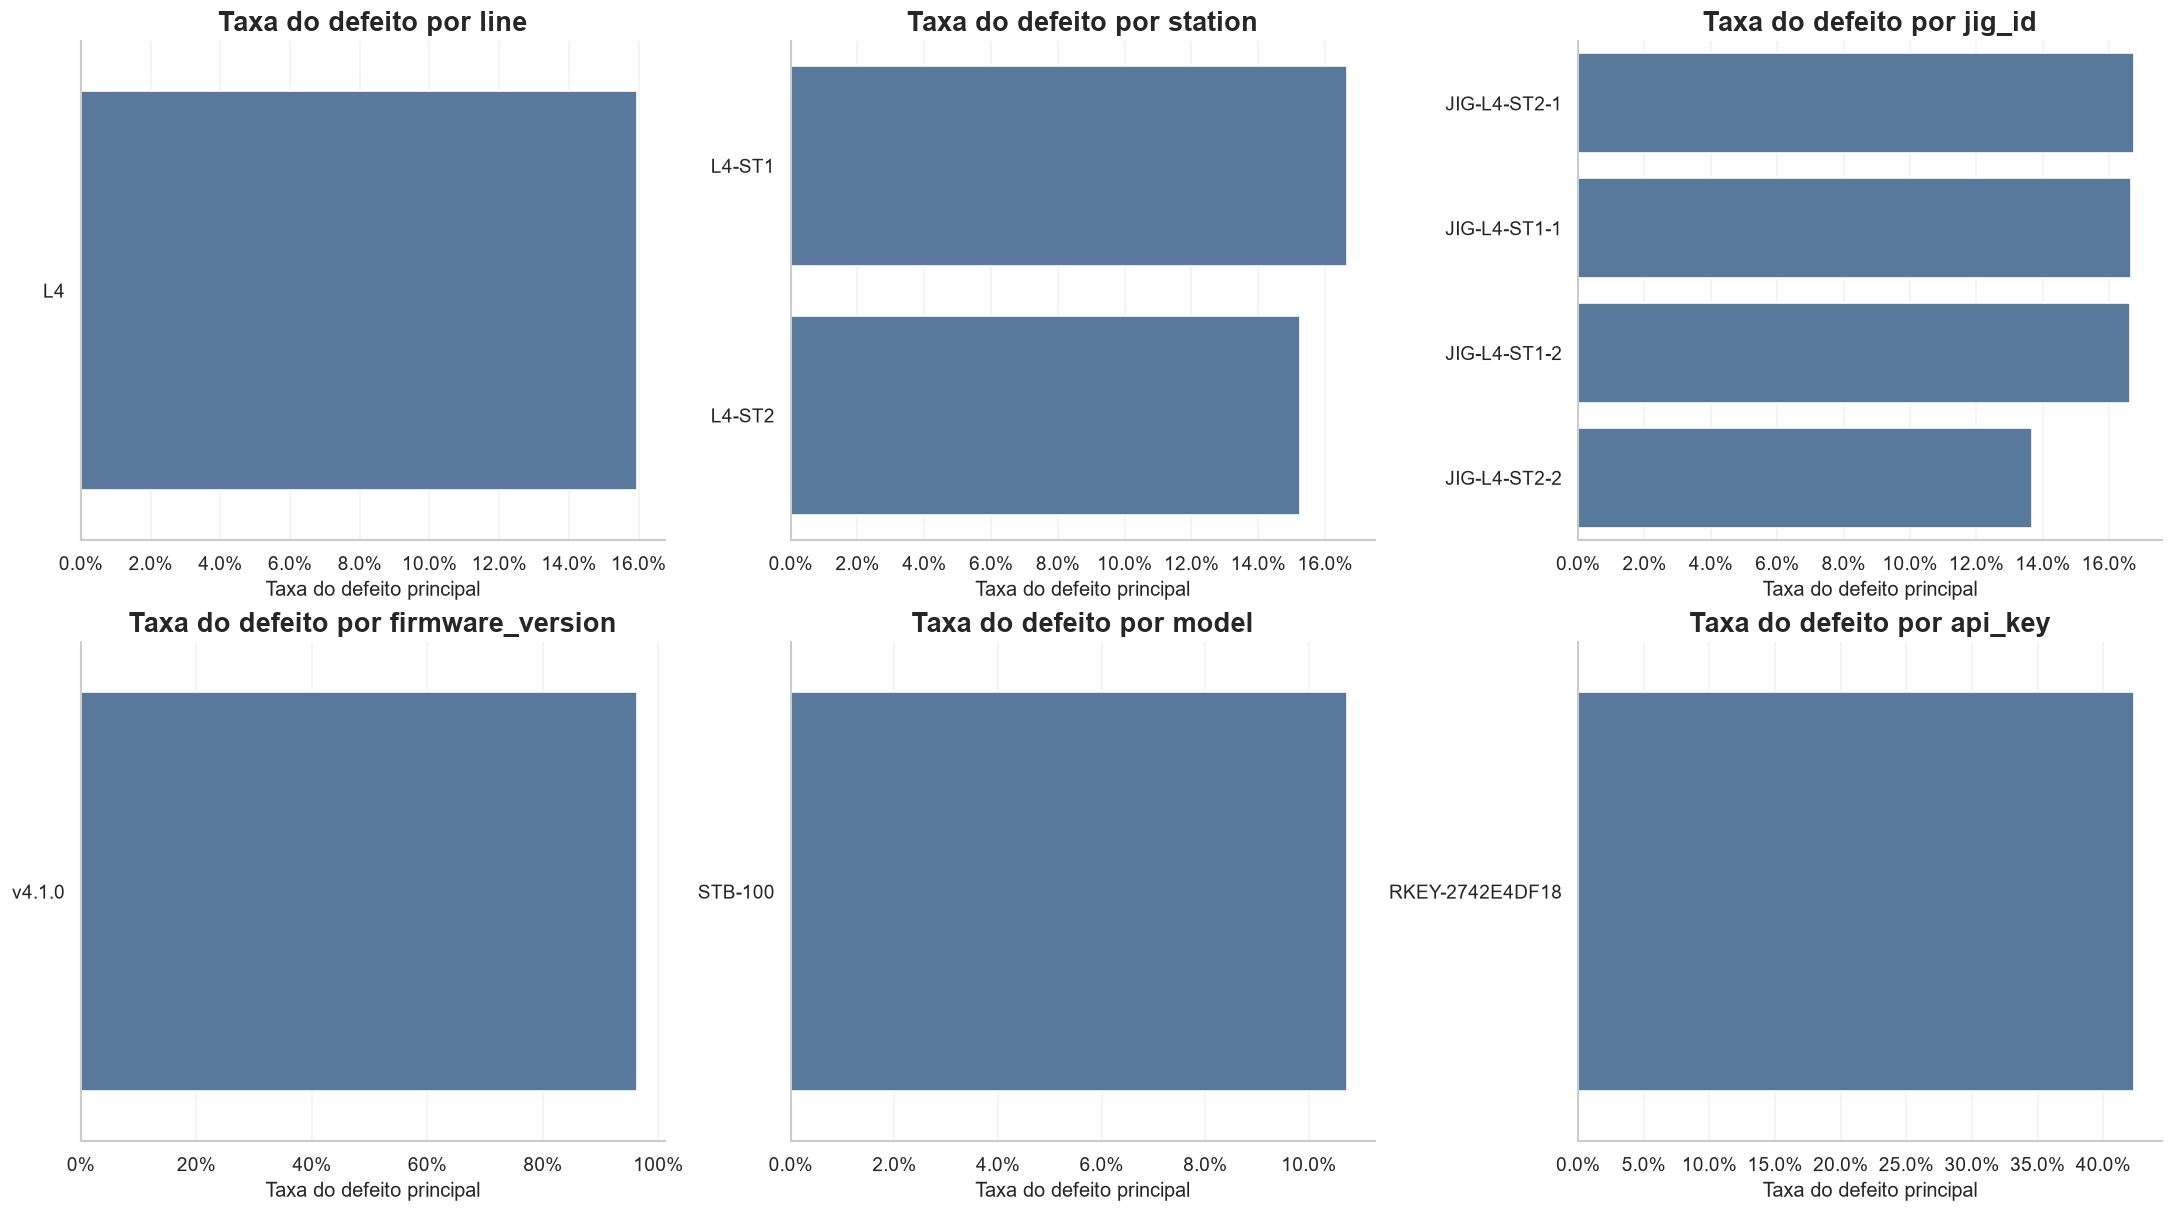

In [208]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

for ax, dimension in zip(axes, where_dimensions):
    summary = (
        where_summaries[dimension]
        .loc[where_summaries[dimension]["main_defects"].gt(0)]
        .head(12)
        .copy()
    )

    if summary.empty:
        ax.text(0.5, 0.5, "Sem ocorrencias", ha="center", va="center")
        ax.set_axis_off()
        continue

    sns.barplot(
        data=summary,
        x="main_defect_rate",
        y=dimension,
        ax=ax,
        color="#4C78A8",
    )
    ax.set_title(f"Taxa do defeito por {dimension}")
    ax.set_xlabel("Taxa do defeito principal")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))

plt.show()

## PPM do defeito principal por linha e jig

PPM = defeitos / tentativas * 1.000.000. Aqui o PPM esta no nivel do defeito principal, nao no nivel de todos os defeitos.

In [209]:
ppm_line = where_summaries["line"][["line", "total_attempts", "main_defects", "main_defect_rate", "ppm_main_defect"]]
ppm_jig = where_summaries["jig_id"][["jig_id", "total_attempts", "main_defects", "main_defect_rate", "ppm_main_defect"]]

ppm_line_display = ppm_line.copy()
ppm_line_display["main_defect_rate"] = ppm_line_display["main_defect_rate"].map("{:.2%}".format)
ppm_line_display["ppm_main_defect"] = ppm_line_display["ppm_main_defect"].map("{:,.0f}".format)

ppm_jig_display = ppm_jig.copy()
ppm_jig_display["main_defect_rate"] = ppm_jig_display["main_defect_rate"].map("{:.2%}".format)
ppm_jig_display["ppm_main_defect"] = ppm_jig_display["ppm_main_defect"].map("{:,.0f}".format)

display(ppm_line_display)
display(ppm_jig_display.head(12))

,line,total_attempts,main_defects,main_defect_rate,ppm_main_defect
3,L4,3755,599,15.95%,"159,521"
0,L1,5141,0,0.00%,0
1,L2,5154,0,0.00%,0
2,L3,3794,0,0.00%,0


,jig_id,total_attempts,main_defects,main_defect_rate,ppm_main_defect
14,JIG-L4-ST2-1,961,161,16.75%,"167,534"
12,JIG-L4-ST1-1,948,158,16.67%,"166,667"
13,JIG-L4-ST1-2,932,155,16.63%,"166,309"
15,JIG-L4-ST2-2,914,125,13.68%,"136,761"
0,JIG-L1-ST1-1,1326,0,0.00%,0
1,JIG-L1-ST1-2,1274,0,0.00%,0
2,JIG-L1-ST2-1,1267,0,0.00%,0
3,JIG-L1-ST2-2,1274,0,0.00%,0
7,JIG-L2-ST2-2,1291,0,0.00%,0
6,JIG-L2-ST2-1,1311,0,0.00%,0


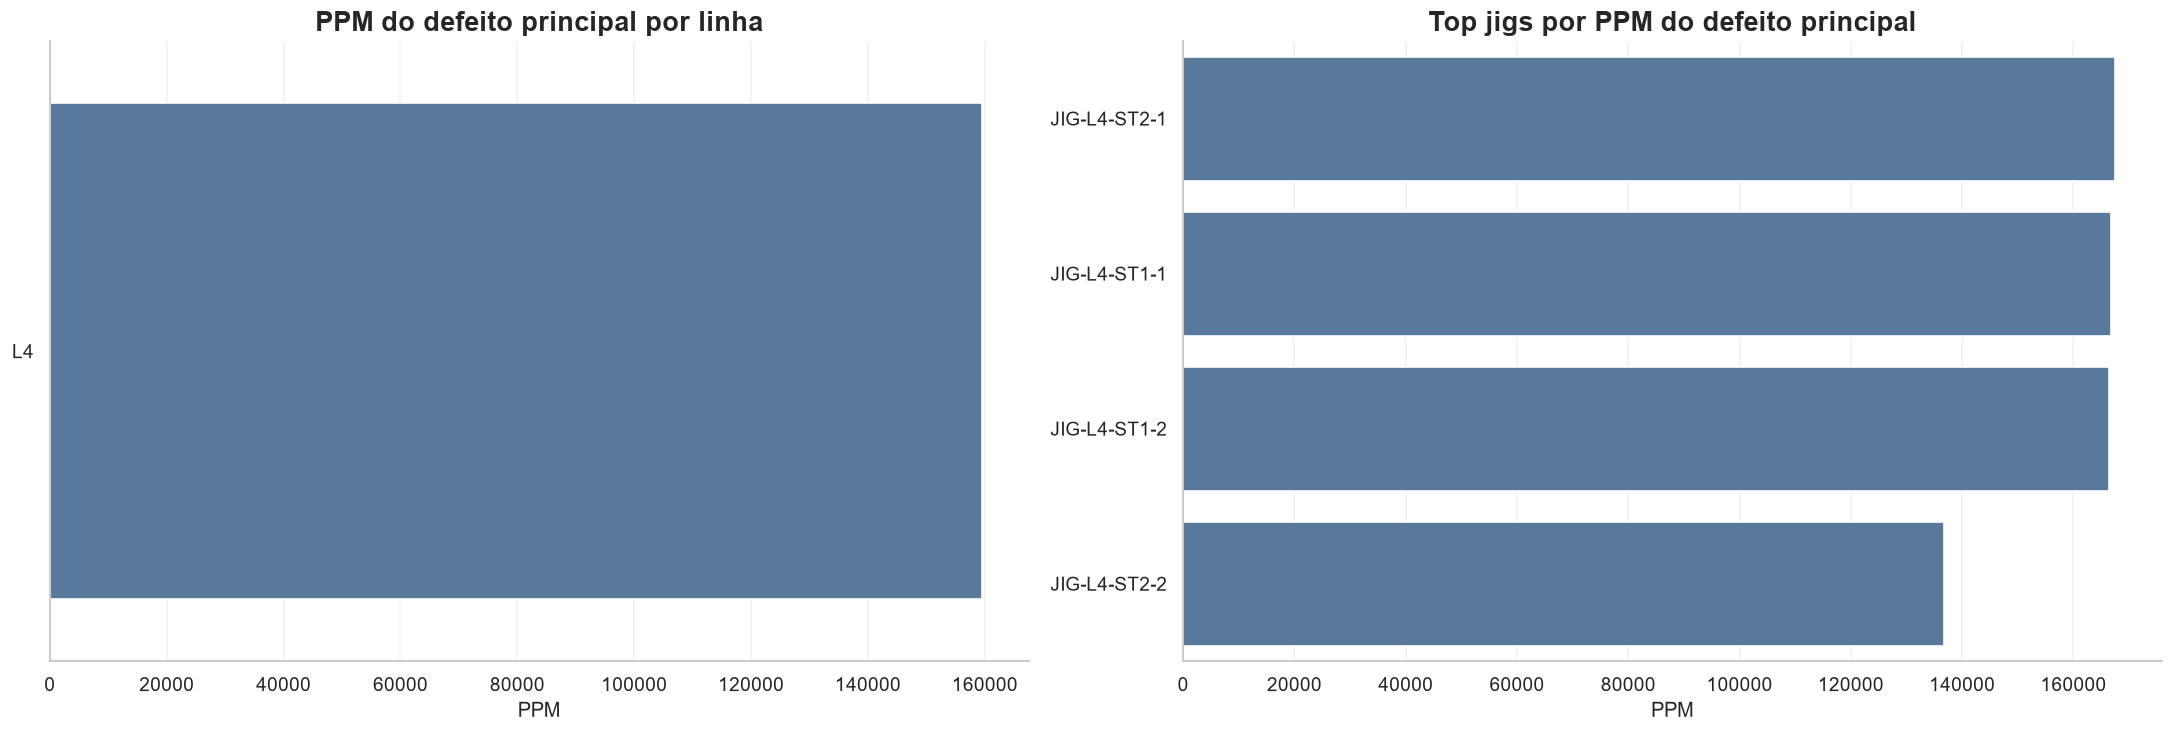

In [210]:
ppm_line_plot = ppm_line.loc[ppm_line["main_defects"].gt(0)].copy()
ppm_jig_plot = ppm_jig.loc[ppm_jig["main_defects"].gt(0)].head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.barplot(
    data=ppm_line_plot,
    x="ppm_main_defect",
    y="line",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("PPM do defeito principal por linha")
axes[0].set_xlabel("PPM")
axes[0].set_ylabel("")

sns.barplot(
    data=ppm_jig_plot,
    x="ppm_main_defect",
    y="jig_id",
    ax=axes[1],
    color="#4C78A8",
)
axes[1].set_title("Top jigs por PPM do defeito principal")
axes[1].set_xlabel("PPM")
axes[1].set_ylabel("")

plt.show()

O PPM por linha e jig confirma que o defeito principal está altamente concentrado na L4. Os quatro jigs da L4 apresentam PPM muito superior aos demais, indicando uma causa sistêmica da linha ou do lote/configuração usada nela, e não uma falha isolada de equipamento.

## Quando o defeito principal aconteceu

A serie temporal abaixo usa janelas de 30 minutos. A linha mais escura e a media movel de 3 janelas, usada para reduzir ruido e deixar mais claro quando o problema comeca ou se intensifica.

In [211]:
time_summary = (
    analysis_df
    .set_index("timestamp")
    .groupby(pd.Grouper(freq="30min"))
    .agg(
        total_attempts=("result", "size"),
        total_failures=("is_fail", "sum"),
        main_defects=("is_main_defect", "sum"),
    )
    .query("total_attempts > 0")
    .reset_index()
)

time_summary["main_defect_rate"] = time_summary["main_defects"] / time_summary["total_attempts"]
time_summary["failure_rate"] = time_summary["total_failures"] / time_summary["total_attempts"]
time_summary["main_defect_rate_ma3"] = time_summary["main_defect_rate"].rolling(3, min_periods=1).mean()

display(
    time_summary.sort_values("main_defect_rate", ascending=False)
    .head(12)
    .assign(
        main_defect_rate=lambda df: df["main_defect_rate"].map("{:.2%}".format),
        failure_rate=lambda df: df["failure_rate"].map("{:.2%}".format),
        main_defect_rate_ma3=lambda df: df["main_defect_rate_ma3"].map("{:.2%}".format),
    )
)

,timestamp,total_attempts,total_failures,main_defects,main_defect_rate,failure_rate,main_defect_rate_ma3
32,2022-09-12 22:00:00,25,16,13,52.00%,64.00%,26.59%
34,2022-09-12 23:00:00,13,5,3,23.08%,38.46%,28.73%
31,2022-09-12 21:30:00,160,40,23,14.37%,25.00%,12.09%
30,2022-09-12 21:00:00,194,39,26,13.40%,20.10%,11.63%
6,2022-09-12 09:00:00,181,33,24,13.26%,18.23%,11.92%
28,2022-09-12 20:00:00,177,35,23,12.99%,19.77%,11.56%
24,2022-09-12 18:00:00,206,41,25,12.14%,19.90%,10.01%
4,2022-09-12 08:00:00,176,37,21,11.93%,21.02%,9.99%
26,2022-09-12 19:00:00,194,43,23,11.86%,22.16%,10.58%
10,2022-09-12 11:00:00,186,34,21,11.29%,18.28%,10.96%


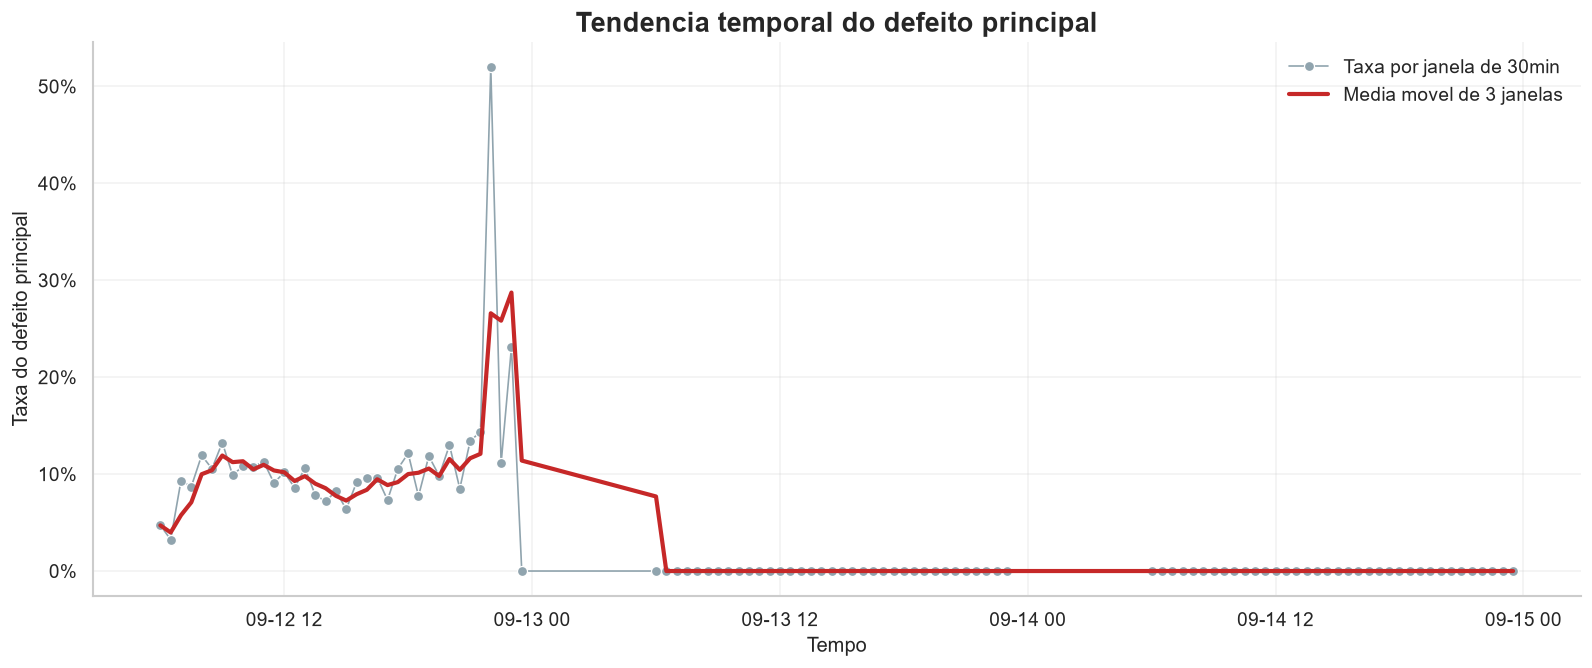

In [212]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.lineplot(
    data=time_summary,
    x="timestamp",
    y="main_defect_rate",
    ax=ax,
    color="#90A4AE",
    marker="o",
    linewidth=1,
    label="Taxa por janela de 30min",
)

sns.lineplot(
    data=time_summary,
    x="timestamp",
    y="main_defect_rate_ma3",
    ax=ax,
    color="#C62828",
    linewidth=2.5,
    label="Media movel de 3 janelas",
)

ax.set_title("Tendencia temporal do defeito principal")
ax.set_xlabel("Tempo")
ax.set_ylabel("Taxa do defeito principal")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.legend(loc="upper right")

plt.show()

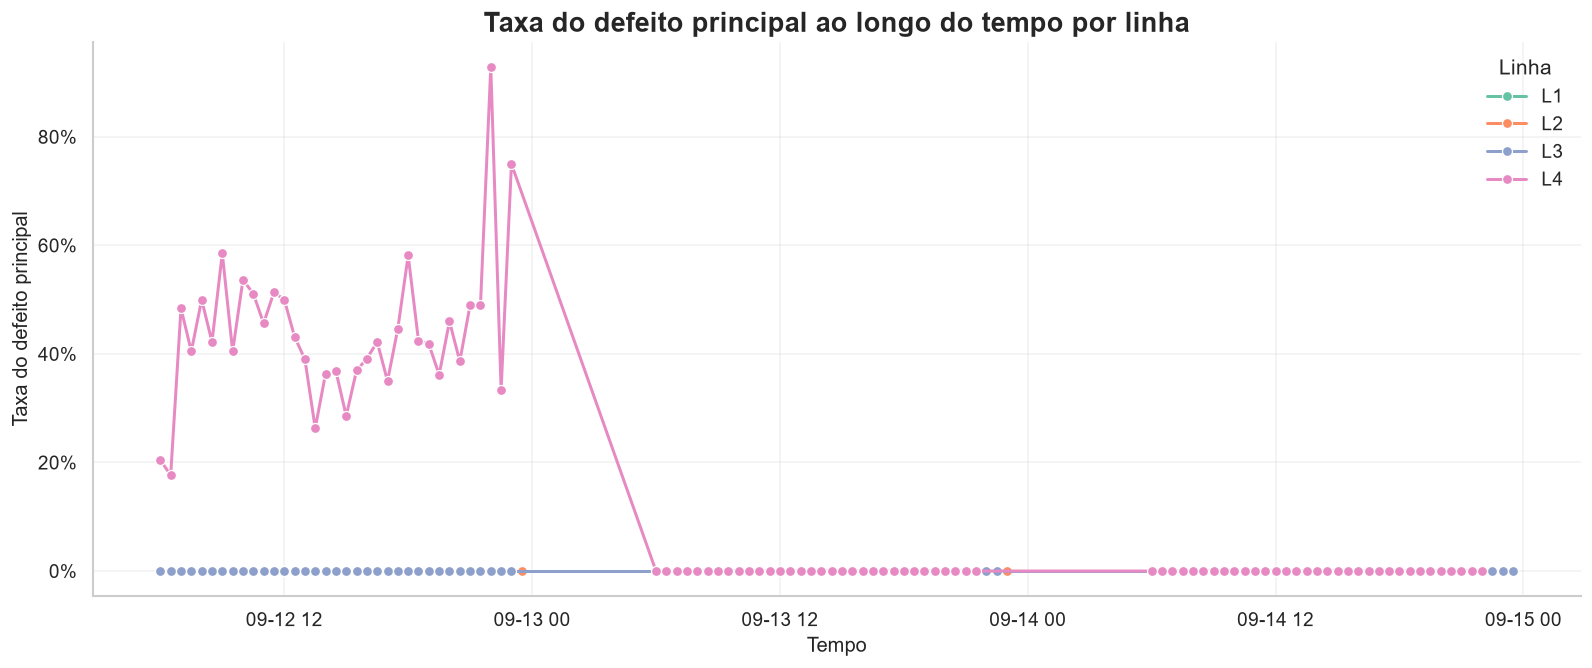

In [213]:
line_time_summary = (
    analysis_df
    .set_index("timestamp")
    .groupby(["line", pd.Grouper(freq="30min")])
    .agg(
        total_attempts=("result", "size"),
        main_defects=("is_main_defect", "sum"),
    )
    .query("total_attempts > 0")
    .reset_index()
)

line_time_summary["main_defect_rate"] = line_time_summary["main_defects"] / line_time_summary["total_attempts"]

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(
    data=line_time_summary,
    x="timestamp",
    y="main_defect_rate",
    hue="line",
    marker="o",
    linewidth=1.8,
    ax=ax,
)

ax.set_title("Taxa do defeito principal ao longo do tempo por linha")
ax.set_xlabel("Tempo")
ax.set_ylabel("Taxa do defeito principal")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.legend(title="Linha", loc="upper right")

plt.show()

Com o par estrito `drm_keys + ERR_DRM`, o defeito fica concentrado em `2022-09-12`, do inicio da producao ate o fim da noite. Depois de `2022-09-13`, esse par especifico praticamente desaparece. Isso reforca a hipotese de um lote/configuracao usado na L4 naquele dia, ligado ao firmware `v4.1.0`, ao modelo `STB-100` e a API key `RKEY-2742E4DF18`.

# Correcoes complementares em relacao ao desafio

Os blocos abaixo cobrem pontos como: KPIs, yield, DPMO, disponibilidade/downtime, visao `jig x etapa`, cycle time, rework/scrap, acesso remoto, Bluetooth/cabo, integridade e base de auditoria.

In [214]:
# Preparacao comum para as metricas do desafio.
analysis_df = dataset.copy()
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"])
analysis_df["date"] = pd.to_datetime(analysis_df["date"])
analysis_df["is_fail"] = analysis_df["result"].eq("FAIL")
analysis_df["is_pass"] = analysis_df["result"].eq("PASS")

line_stops_df = line_stops.copy()
line_stops_df["stop_start"] = pd.to_datetime(line_stops_df["stop_start"])
line_stops_df["stop_end"] = pd.to_datetime(line_stops_df["stop_end"])

PROCESS_STEPS = [
    "fw_download", "bootloader", "kernel", "rootfs", "secure_boot",
    "mac_write", "wifi_cal", "bluetooth", "cable_scan", "hdmi_edid",
    "dvb_tuner", "drm_keys", "final_check",
]
OK_COLUMNS = [f"{step}_ok" for step in PROCESS_STEPS if f"{step}_ok" in analysis_df.columns]
CYCLE_COLUMNS = [f"{step}_cycle_s" for step in PROCESS_STEPS if f"{step}_cycle_s" in analysis_df.columns]

attempt1 = analysis_df.loc[analysis_df["attempt"].eq(1)].copy()
serial_final = (
    analysis_df.groupby("serial_number")
    .agg(
        any_pass=("result", lambda s: s.eq("PASS").any()),
        max_attempt=("attempt", "max"),
        final_scrap=("disposition", lambda s: s.eq("SCRAP").any()),
        attempts_recorded=("attempt", "size"),
    )
    .reset_index()
)
serial_base = attempt1.merge(serial_final, on="serial_number", how="left")

## KPIs solicitados

Assumimos `Y` como seriais com algum `PASS` final e `H` como o intervalo observado entre o primeiro e o ultimo timestamp. Para dashboard final, essa premissa pode ser refinada com calendario planejado de producao.

In [215]:
total_attempts = len(analysis_df)
total_serials = analysis_df["serial_number"].nunique()
total_failures = analysis_df["is_fail"].sum()
first_pass_serials = attempt1.loc[attempt1["result"].eq("PASS"), "serial_number"].nunique()
final_pass_serials = serial_final["any_pass"].sum()
reworked_serials = serial_final["max_attempt"].gt(1).sum()
scrap_serials = serial_final["final_scrap"].sum()

elapsed_hours = (analysis_df["timestamp"].max() - analysis_df["timestamp"].min()) / pd.Timedelta(hours=1)
station_count = analysis_df["station"].nunique()
operator_count = analysis_df["operator"].nunique()

fpy = first_pass_serials / total_serials
final_yield = final_pass_serials / total_serials
rework_rate = reworked_serials / total_serials
scrap_rate = scrap_serials / total_serials
unit_ppm = (1 - fpy) * 1_000_000
opportunities = analysis_df[OK_COLUMNS].notna().sum().sum()
dpmo = total_failures / opportunities * 1_000_000
uph = final_pass_serials / elapsed_hours
uph_per_station = final_pass_serials / (station_count * elapsed_hours)

kpi_table = pd.DataFrame([
    ["Tentativas registradas", total_attempts, "count", "linhas"],
    ["Seriais unicos", total_serials, "count", "unidades"],
    ["Falhas registradas", total_failures, "count", "tentativas FAIL"],
    ["FPY", fpy, "pct", "seriais PASS na tentativa 1 / seriais"],
    ["Yield final", final_yield, "pct", "seriais com algum PASS / seriais"],
    ["Taxa de rework", rework_rate, "pct", "seriais com attempt > 1 / seriais"],
    ["Taxa de scrap", scrap_rate, "pct", "seriais com SCRAP / seriais"],
    ["PPM unidade", unit_ppm, "ppm", "(1 - FPY) * 1.000.000"],
    ["DPMO geral", dpmo, "ppm", "falhas / oportunidades de etapa * 1.000.000"],
    ["UPH", uph, "number", "unidades finais PASS / hora observada"],
    ["UPH por estacao", uph_per_station, "number", "unidades finais PASS / (S * H)"],
    ["Estacoes", station_count, "count", "S"],
    ["Operadores", operator_count, "count", "P"],
    ["Horas observadas", elapsed_hours, "number", "H"],
], columns=["metric", "value", "format", "definition"])

def format_kpi(row):
    if row["format"] == "pct":
        return f"{row['value']:.2%}"
    if row["format"] == "ppm":
        return f"{row['value']:,.0f}"
    if row["format"] == "count":
        return f"{row['value']:,.0f}"
    return f"{row['value']:,.2f}"

kpi_display = kpi_table.copy()
kpi_display["value"] = kpi_display.apply(format_kpi, axis=1)
kpi_display = kpi_display.drop(columns="format")
display(kpi_display)

,metric,value,definition
0,Tentativas registradas,"17,844",linhas
1,Seriais unicos,"16,115",unidades
2,Falhas registradas,"2,296",tentativas FAIL
3,FPY,89.27%,seriais PASS na tentativa 1 / seriais
4,Yield final,96.48%,seriais com algum PASS / seriais
5,Taxa de rework,10.73%,seriais com attempt > 1 / seriais
6,Taxa de scrap,3.52%,seriais com SCRAP / seriais
7,PPM unidade,"107,291",(1 - FPY) * 1.000.000
8,DPMO geral,"10,651",falhas / oportunidades de etapa * 1.000.000
9,UPH,237.26,unidades finais PASS / hora observada


## Yield por linha, estacao, modelo e firmware

Essa visao atende ao pedido de yield por dimensoes produtivas. O calculo usa seriais de primeira tentativa como base para nao duplicar rework.

Yield por line


,line,serials,fpy,final_yield,rework_rate,scrap_rate
2,L3,3212,81.88%,94.96%,18.12%,5.04%
3,L4,3260,84.82%,89.88%,15.18%,10.12%
1,L2,4783,92.24%,98.81%,7.76%,1.19%
0,L1,4860,94.22%,99.63%,5.78%,0.37%


Yield por station


,station,serials,fpy,final_yield,rework_rate,scrap_rate
5,L3-ST2,1628,69.90%,90.42%,30.10%,9.58%
6,L4-ST1,1621,84.02%,89.27%,15.98%,10.73%
7,L4-ST2,1639,85.60%,90.48%,14.40%,9.52%
2,L2-ST1,2366,92.14%,99.07%,7.86%,0.93%
3,L2-ST2,2417,92.35%,98.55%,7.65%,1.45%
1,L1-ST2,2401,94.17%,99.63%,5.83%,0.37%
4,L3-ST1,1584,94.19%,99.62%,5.81%,0.38%
0,L1-ST1,2459,94.27%,99.63%,5.73%,0.37%


Yield por model


,model,serials,fpy,final_yield,rework_rate,scrap_rate
0,STB-100,4874,85.49%,92.18%,14.51%,7.82%
3,STB-400,2417,90.40%,98.51%,9.60%,1.49%
2,STB-300,4003,90.66%,98.15%,9.34%,1.85%
1,STB-200,4821,91.37%,98.42%,8.63%,1.58%


Yield por firmware_version


,firmware_version,serials,fpy,final_yield,rework_rate,scrap_rate
0,v4.1.0,311,0.00%,0.00%,100.00%,100.00%
1,v4.1.2,15804,91.03%,98.38%,8.97%,1.62%


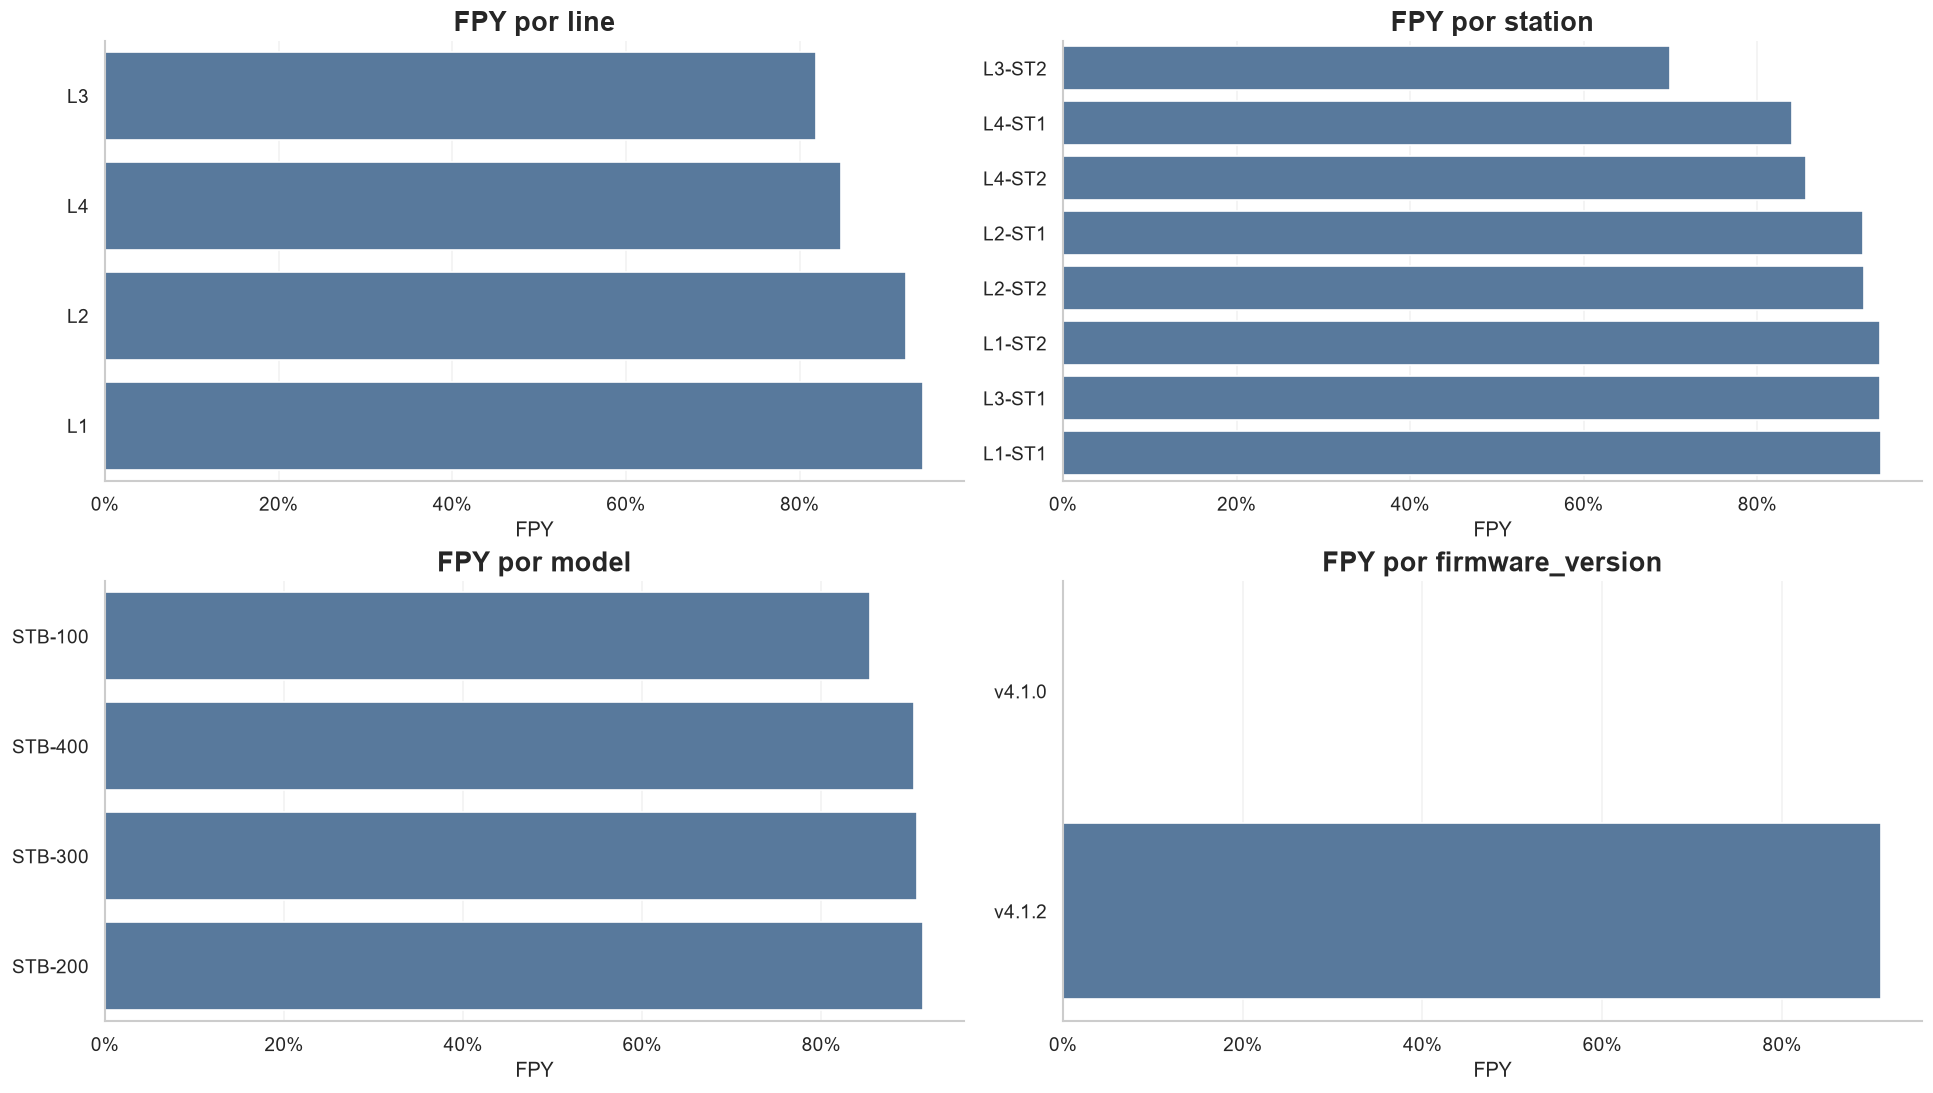

In [216]:
def yield_summary_by(dimension):
    summary = (
        serial_base.groupby(dimension, dropna=False)
        .agg(
            serials=("serial_number", "nunique"),
            fpy=("result", lambda s: s.eq("PASS").mean()),
            final_yield=("any_pass", "mean"),
            rework_rate=("max_attempt", lambda s: s.gt(1).mean()),
            scrap_rate=("final_scrap", "mean"),
        )
        .reset_index()
        .sort_values("fpy")
    )
    return summary

YIELD_DIMENSIONS = ["line", "station", "model", "firmware_version"]
yield_summaries = {dimension: yield_summary_by(dimension) for dimension in YIELD_DIMENSIONS}

for dimension, summary in yield_summaries.items():
    display_df = summary.copy()
    for col in ["fpy", "final_yield", "rework_rate", "scrap_rate"]:
        display_df[col] = display_df[col].map("{:.2%}".format)
    print(f"Yield por {dimension}")
    display(display_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)
for ax, dimension in zip(axes.flatten(), YIELD_DIMENSIONS):
    sns.barplot(data=yield_summaries[dimension], x="fpy", y=dimension, ax=ax, color="#4C78A8")
    ax.set_title(f"FPY por {dimension}")
    ax.set_xlabel("FPY")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.show()

## DPMO por etapa

O DPMO por etapa ajuda a comparar etapas com quantidades diferentes de oportunidades. Bluetooth e cabo aparecem com menos oportunidades porque nao se aplicam a todos os modelos.

,step,opportunities,defects,defect_rate,dpmo
11,drm_keys,17844,669,3.75%,"37,492"
3,rootfs,17844,627,3.51%,"35,138"
0,fw_download,17844,242,1.36%,"13,562"
8,cable_scan,12263,105,0.86%,"8,562"
7,bluetooth,7026,41,0.58%,"5,835"
6,wifi_cal,17844,97,0.54%,"5,436"
2,kernel,17844,85,0.48%,"4,764"
10,dvb_tuner,17844,83,0.47%,"4,651"
9,hdmi_edid,17844,76,0.43%,"4,259"
4,secure_boot,17844,73,0.41%,"4,091"


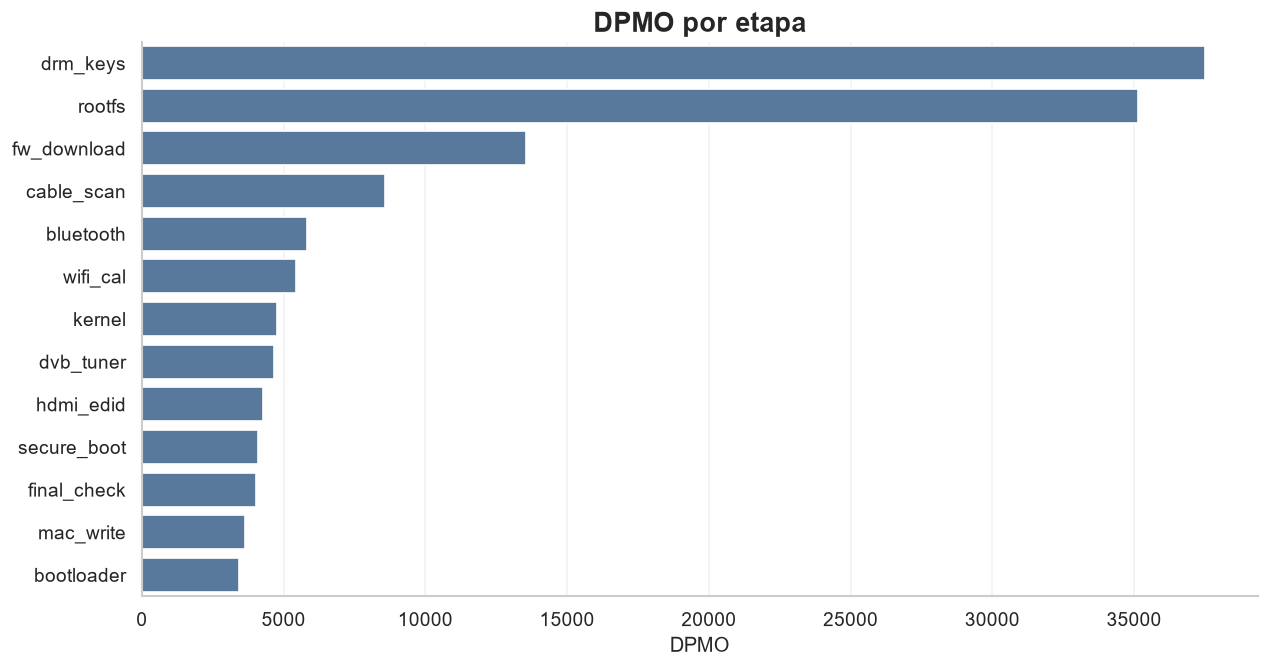

In [217]:
dpmo_rows = []
for step in PROCESS_STEPS:
    ok_col = f"{step}_ok"
    if ok_col not in analysis_df.columns:
        continue
    opportunities_step = analysis_df[ok_col].notna().sum()
    defects_step = analysis_df["failed_step"].eq(step).sum()
    dpmo_step = defects_step / opportunities_step * 1_000_000 if opportunities_step else np.nan
    dpmo_rows.append({
        "step": step,
        "opportunities": opportunities_step,
        "defects": defects_step,
        "defect_rate": defects_step / opportunities_step if opportunities_step else np.nan,
        "dpmo": dpmo_step,
    })

dpmo_by_step = pd.DataFrame(dpmo_rows).sort_values("dpmo", ascending=False)
display(
    dpmo_by_step.assign(
        defect_rate=lambda df: df["defect_rate"].map("{:.2%}".format),
        dpmo=lambda df: df["dpmo"].map("{:,.0f}".format),
    )
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=dpmo_by_step, x="dpmo", y="step", ax=ax, color="#4C78A8")
ax.set_title("DPMO por etapa")
ax.set_xlabel("DPMO")
ax.set_ylabel("")
plt.show()

## Visao jig x etapa

Essa matriz atende ao requisito de expor equipamento cronico. Valores sao taxas: falhas daquela etapa divididas pelo total de tentativas daquele jig.

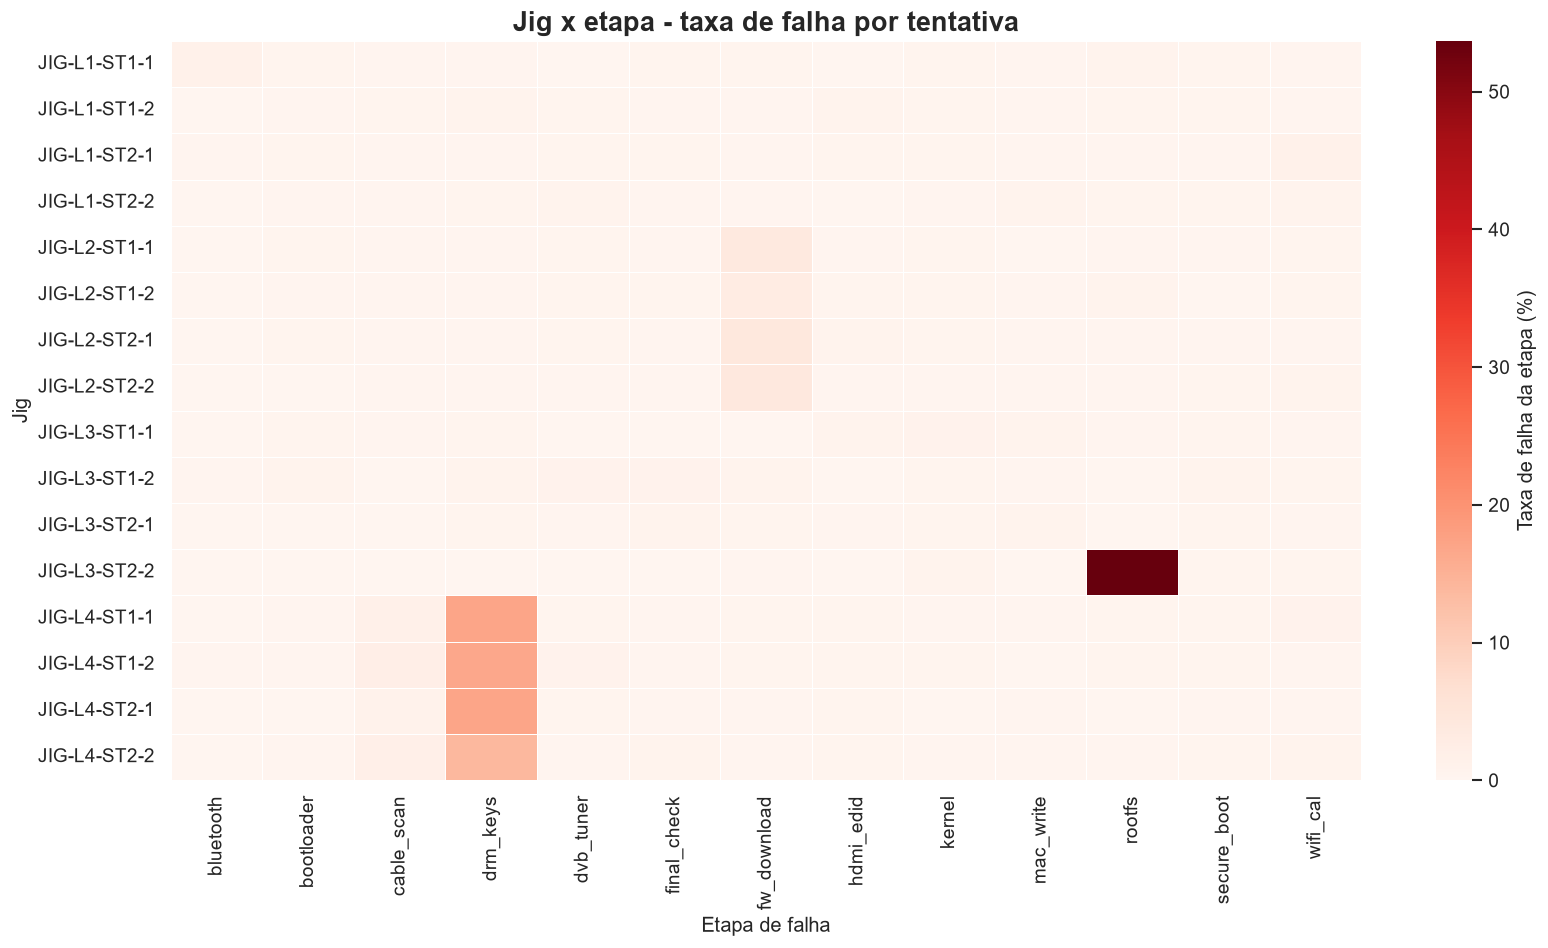

failed_step,bluetooth,bootloader,cable_scan,drm_keys,dvb_tuner,final_check,fw_download,hdmi_edid,kernel,mac_write,rootfs,secure_boot,wifi_cal
jig_id,,,,,,,,,,,,,
JIG-L1-ST1-1,1.28,0.45,0.23,0.38,0.15,0.60,0.45,0.08,0.45,0.30,0.75,0.45,0.38
JIG-L1-ST1-2,0.08,0.39,0.47,0.71,0.47,0.24,0.31,0.71,0.47,0.39,0.47,0.55,0.31
JIG-L1-ST2-1,0.24,0.47,0.32,0.32,0.47,0.55,0.24,0.55,0.55,0.39,0.32,0.24,1.42
JIG-L1-ST2-2,0.16,0.31,0.31,0.63,0.71,0.24,0.24,0.16,0.39,0.71,0.55,0.55,0.71
JIG-L2-ST1-1,0.15,0.46,0.38,0.38,0.53,0.31,3.89,0.38,0.53,0.15,0.23,0.23,0.53
JIG-L2-ST1-2,0.16,0.40,0.24,0.40,0.56,0.56,3.06,0.48,0.48,0.32,0.81,0.16,0.48
JIG-L2-ST2-1,0.00,0.53,0.31,0.23,0.61,0.31,4.27,0.76,0.53,0.31,0.23,0.23,0.31
JIG-L2-ST2-2,0.15,0.15,0.39,0.31,0.31,0.31,4.03,0.39,0.39,0.31,0.31,0.54,0.70
JIG-L3-ST1-1,0.11,0.46,0.23,0.46,0.11,0.11,0.00,0.69,0.92,0.80,0.34,0.46,0.34


In [218]:
jig_step_counts = pd.crosstab(analysis_df["jig_id"], analysis_df["failed_step"])
jig_attempts = analysis_df.groupby("jig_id").size()
jig_step_rate = jig_step_counts.div(jig_attempts, axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    jig_step_rate * 100,
    cmap="Reds",
    linewidths=0.3,
    linecolor="white",
    annot=False,
    cbar_kws={"label": "Taxa de falha da etapa (%)"},
    ax=ax,
)
ax.set_title("Jig x etapa - taxa de falha por tentativa")
ax.set_xlabel("Etapa de falha")
ax.set_ylabel("Jig")
plt.show()

display((jig_step_rate * 100).round(2))

## Falhas ao longo do tempo com paradas de linha

Alem da serie temporal do defeito principal, o desafio pede sobrepor eventos de `line_stops`. Aqui a taxa geral de falha e plotada por linha, com as paradas sombreadas por categoria.

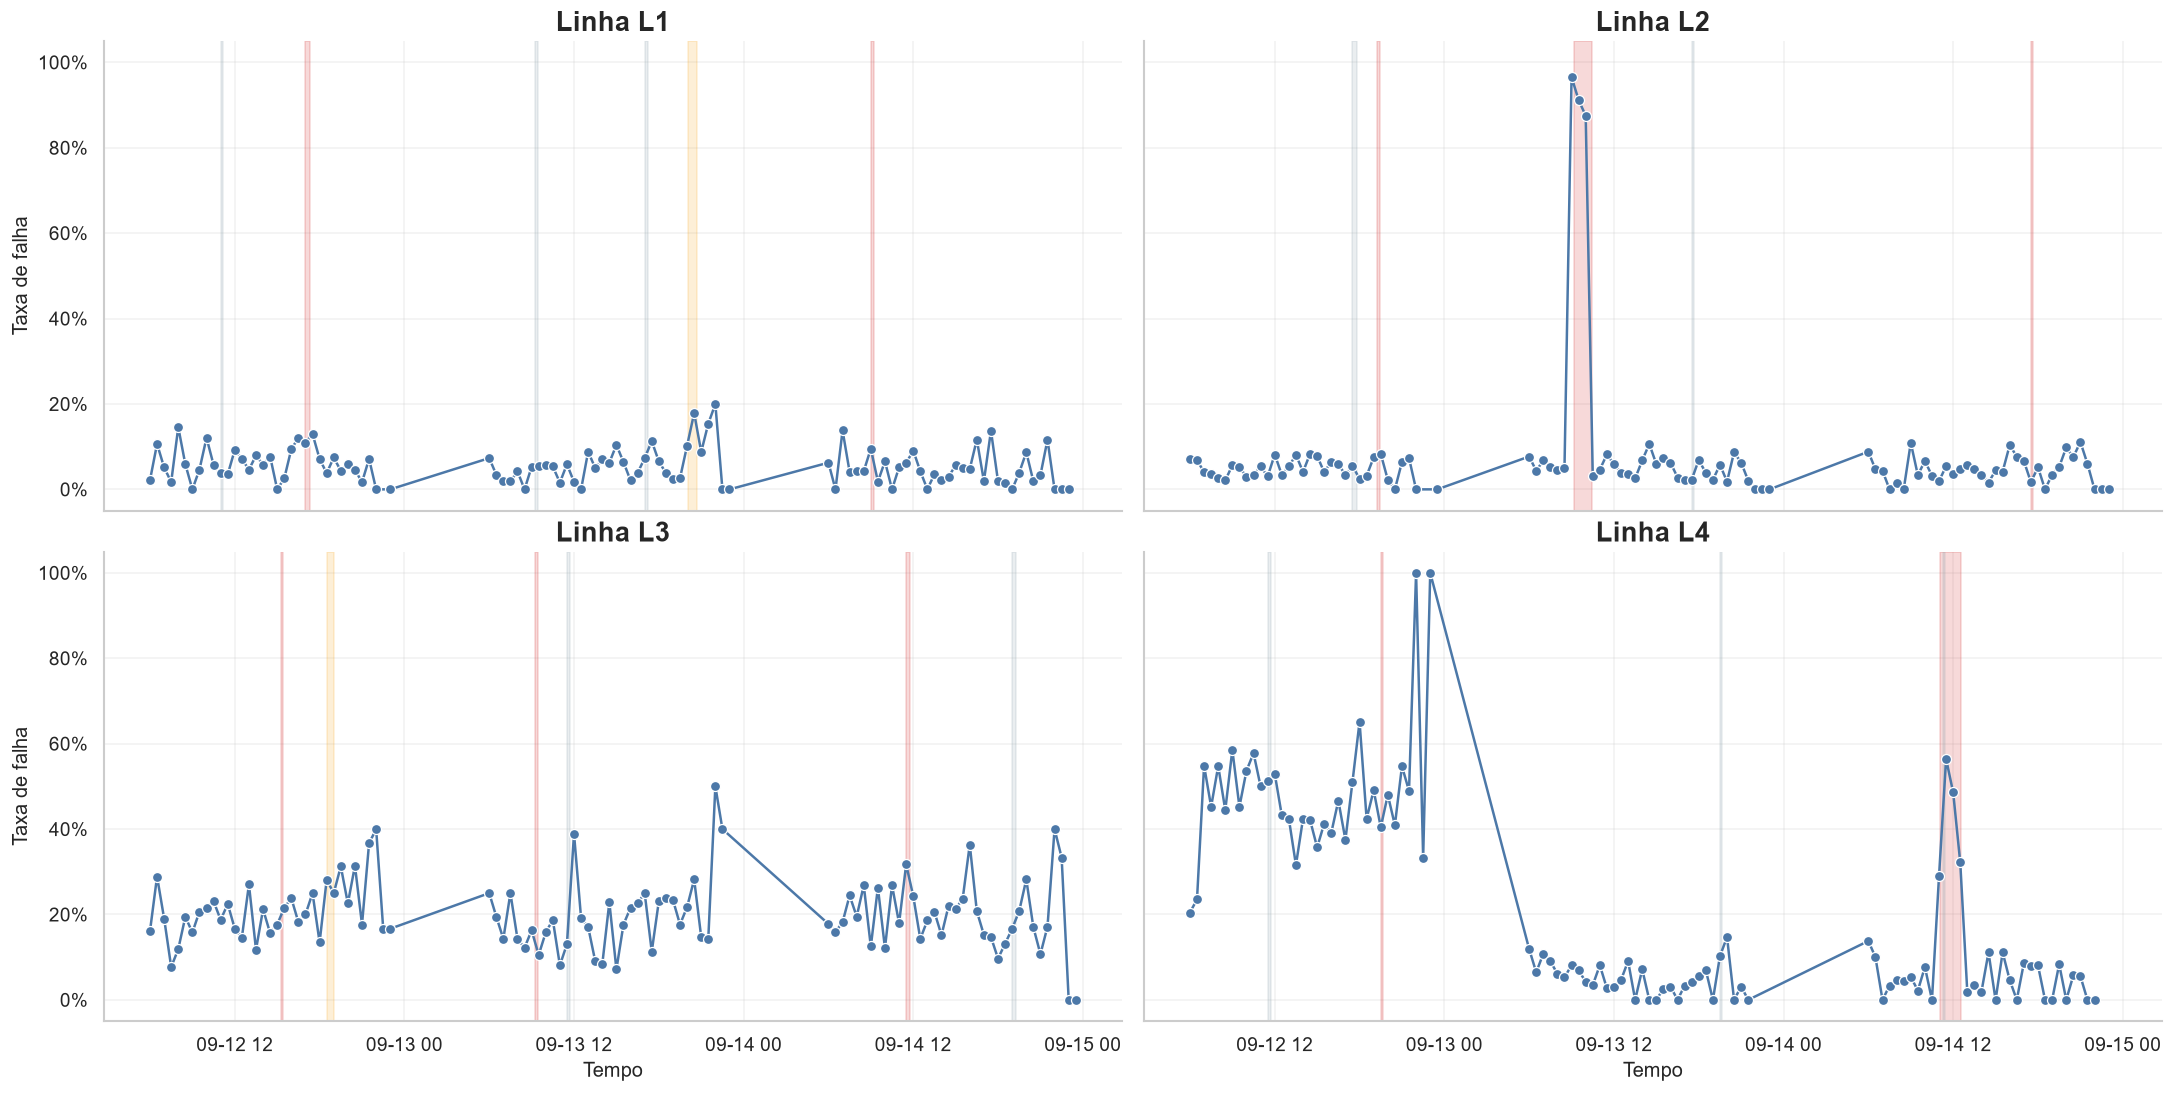

,line,category,stops,downtime_min
0,L1,Maintenance,1,35
2,L1,Unplanned,2,35
1,L1,Planned,3,32
4,L2,Unplanned,3,93
3,L2,Planned,2,30
7,L3,Unplanned,3,35
5,L3,Maintenance,1,30
6,L3,Planned,2,30
9,L4,Unplanned,2,98
8,L4,Planned,3,34


In [219]:
failure_time_by_line = (
    analysis_df
    .set_index("timestamp")
    .groupby(["line", pd.Grouper(freq="30min")])
    .agg(total_attempts=("result", "size"), failures=("is_fail", "sum"))
    .query("total_attempts > 0")
    .reset_index()
)
failure_time_by_line["failure_rate"] = failure_time_by_line["failures"] / failure_time_by_line["total_attempts"]

stop_colors = {
    "Planned": "#90A4AE",
    "Unplanned": "#D32F2F",
    "Maintenance": "#F9A825",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True, sharey=True, constrained_layout=True)
for ax, line in zip(axes.flatten(), sorted(analysis_df["line"].unique())):
    line_data = failure_time_by_line.loc[failure_time_by_line["line"].eq(line)]
    sns.lineplot(data=line_data, x="timestamp", y="failure_rate", marker="o", ax=ax, color="#4C78A8")

    for _, stop in line_stops_df.loc[line_stops_df["line"].eq(line)].iterrows():
        ax.axvspan(
            stop["stop_start"],
            stop["stop_end"],
            color=stop_colors.get(stop["category"], "#BDBDBD"),
            alpha=0.18,
        )

    ax.set_title(f"Linha {line}")
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Taxa de falha")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

plt.show()

downtime_summary = (
    line_stops_df.groupby(["line", "category"])
    .agg(stops=("reason", "size"), downtime_min=("duration_min", "sum"))
    .reset_index()
    .sort_values(["line", "downtime_min"], ascending=[True, False])
)
display(downtime_summary)

## Disponibilidade por linha

Como o enunciado nao fornece calendario planejado separado, o tempo planejado abaixo usa o intervalo observado de producao de cada linha como proxy.

In [220]:
line_window = (
    analysis_df.groupby("line")
    .agg(start=("timestamp", "min"), end=("timestamp", "max"))
    .reset_index()
)
line_window["planned_min_proxy"] = (line_window["end"] - line_window["start"]) / pd.Timedelta(minutes=1)
line_downtime = line_stops_df.groupby("line")["duration_min"].sum().reset_index(name="downtime_min")

availability = line_window.merge(line_downtime, on="line", how="left").fillna({"downtime_min": 0})
availability["availability"] = (availability["planned_min_proxy"] - availability["downtime_min"]) / availability["planned_min_proxy"]
availability["downtime_rate"] = availability["downtime_min"] / availability["planned_min_proxy"]

display(
    availability.assign(
        availability=lambda df: df["availability"].map("{:.2%}".format),
        downtime_rate=lambda df: df["downtime_rate"].map("{:.2%}".format),
        planned_min_proxy=lambda df: df["planned_min_proxy"].map("{:,.0f}".format),
    )
)

,line,start,end,planned_min_proxy,downtime_min,availability,downtime_rate
0,L1,2022-09-12 06:00:07,2022-09-14 23:07:33,"3,907",102,97.39%,2.61%
1,L2,2022-09-12 06:00:06,2022-09-14 23:11:23,"3,911",123,96.86%,3.14%
2,L3,2022-09-12 06:01:00,2022-09-14 23:32:03,"3,931",95,97.58%,2.42%
3,L4,2022-09-12 06:01:14,2022-09-14 22:11:45,"3,851",132,96.57%,3.43%


## Cycle time: gargalos e outliers

O gargalo e a etapa com maior mediana/media de tempo. Outlier aqui e definido por `Q3 + 1.5 * IQR` em cada etapa.

,step,n,mean_s,median_s,p95_s,max_s,outlier_threshold_s,outliers
3,rootfs,17844,40.40,40.00,45.30,262.30,48.80,104
8,cable_scan,12263,35.32,35.00,39.70,225.90,42.75,73
6,wifi_cal,17844,30.97,30.10,34.80,193.80,36.90,469
2,kernel,17844,26.44,26.00,29.50,164.70,31.60,152
10,dvb_tuner,17844,18.26,18.00,20.40,124.40,22.00,122
7,bluetooth,7026,16.19,16.00,18.20,102.40,19.60,53
0,fw_download,17844,12.16,12.00,13.60,83.10,14.55,143
11,drm_keys,17844,10.16,10.00,11.30,66.10,12.00,169
1,bootloader,17844,8.08,8.00,9.10,49.80,9.60,118
9,hdmi_edid,17844,8.11,8.00,9.10,53.80,9.60,165


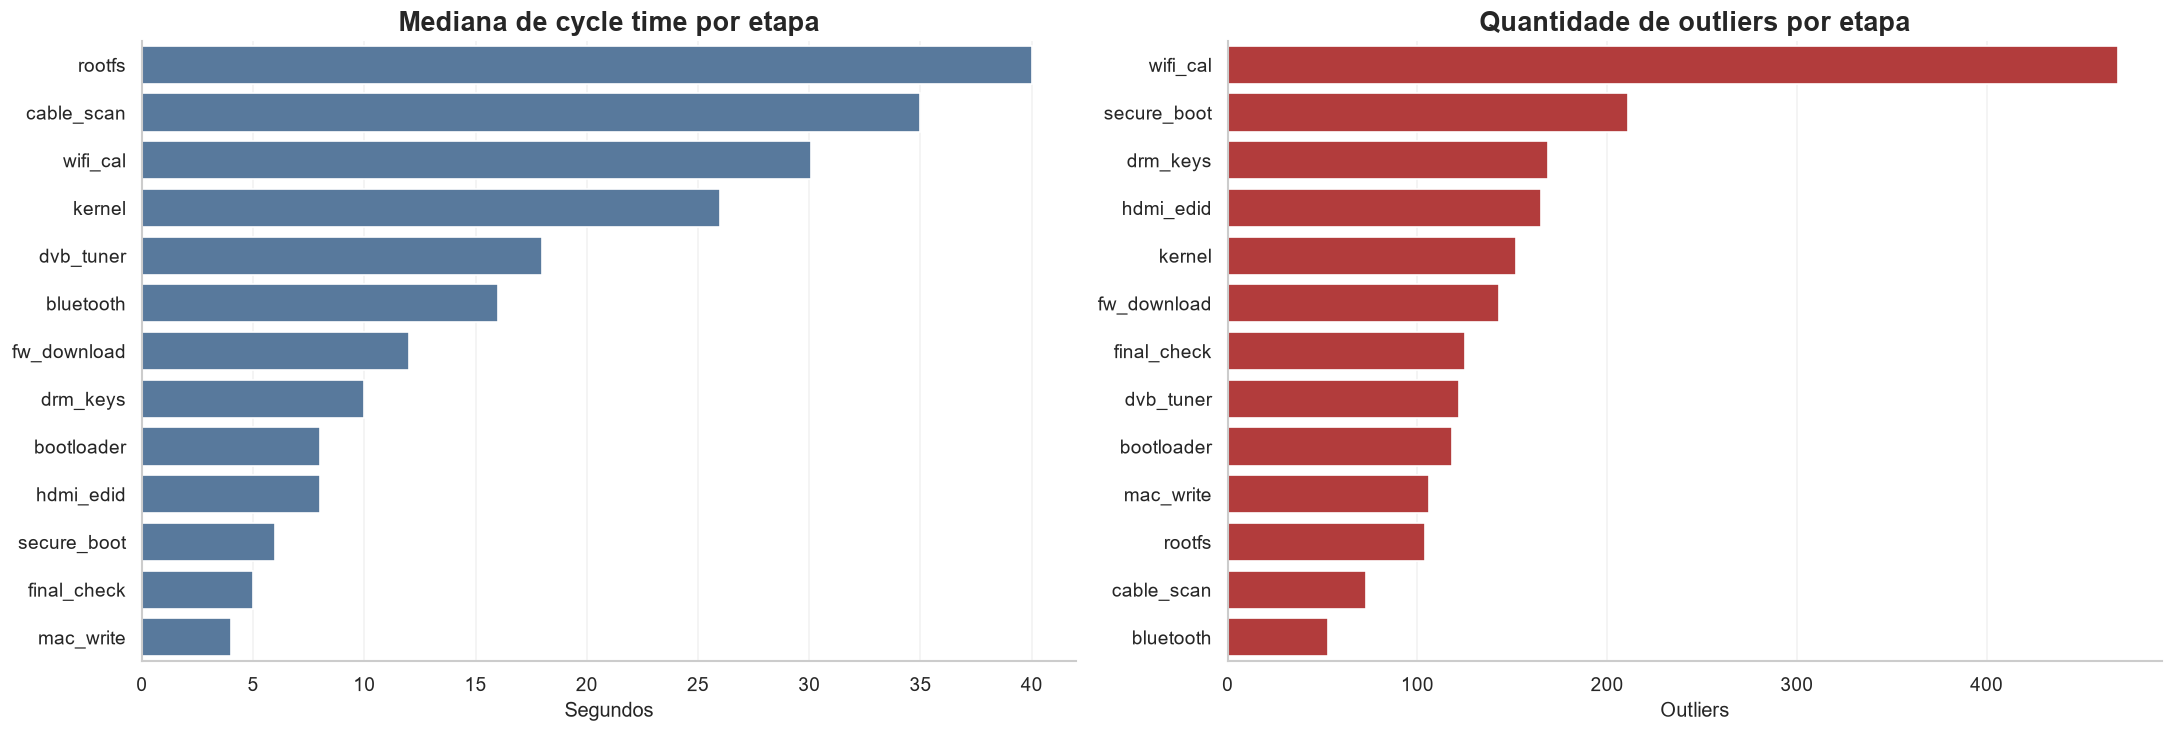

In [221]:
cycle_rows = []
for col in CYCLE_COLUMNS:
    step = col.replace("_cycle_s", "")
    values = analysis_df[col].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    threshold = q3 + 1.5 * iqr
    cycle_rows.append({
        "step": step,
        "n": len(values),
        "mean_s": values.mean(),
        "median_s": values.median(),
        "p95_s": values.quantile(0.95),
        "max_s": values.max(),
        "outlier_threshold_s": threshold,
        "outliers": analysis_df[col].gt(threshold).sum(),
    })

cycle_summary = pd.DataFrame(cycle_rows).sort_values("median_s", ascending=False)
display(cycle_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
sns.barplot(data=cycle_summary, x="median_s", y="step", ax=axes[0], color="#4C78A8")
axes[0].set_title("Mediana de cycle time por etapa")
axes[0].set_xlabel("Segundos")
axes[0].set_ylabel("")

sns.barplot(data=cycle_summary.sort_values("outliers", ascending=False), x="outliers", y="step", ax=axes[1], color="#C62828")
axes[1].set_title("Quantidade de outliers por etapa")
axes[1].set_xlabel("Outliers")
axes[1].set_ylabel("")
plt.show()

## Rework e scrap

Essa quebra mostra a saida do processo e quais defeitos geram mais scrap.

,disposition,attempts
0,PASS,15548
1,REWORK,1729
2,SCRAP,567


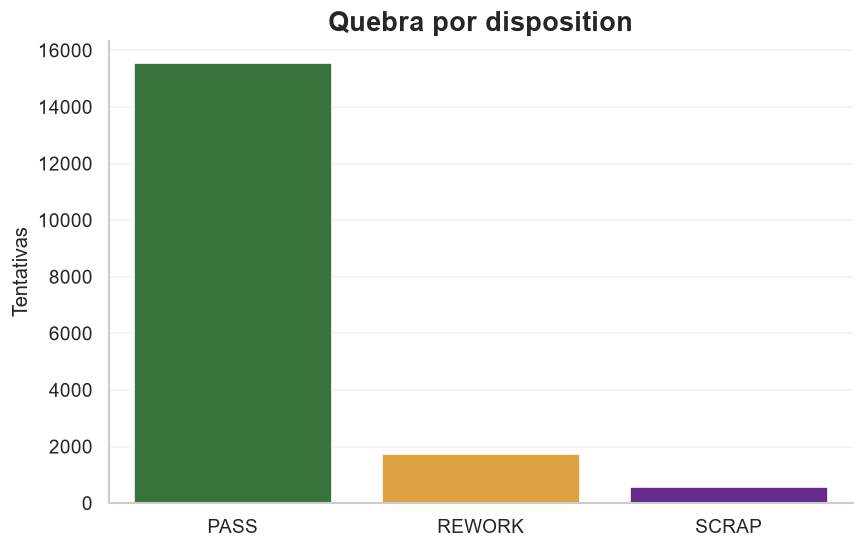

,failed_step,error_code,line,scrap_count
12,drm_keys,ERR_DRM,L4,295
47,rootfs,ERR_MD5,L3,143
26,fw_download,ERR_AUTH,L2,48
10,cable_scan,ERR_NO_SIGNAL,L4,12
0,bluetooth,ERR_BT_CAL,L1,3
21,dvb_tuner,ERR_GLITCH,L4,3
34,hdmi_edid,ERR_GLITCH,L4,3
20,dvb_tuner,ERR_GLITCH,L3,2
19,dvb_tuner,ERR_GLITCH,L2,2
23,final_check,ERR_GLITCH,L3,2


In [222]:
disposition_counts = analysis_df["disposition"].value_counts().rename_axis("disposition").reset_index(name="attempts")
display(disposition_counts)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=disposition_counts,
    x="disposition",
    y="attempts",
    hue="disposition",
    palette=STATUS_PALETTE,
    legend=False,
    ax=ax,
)
ax.set_title("Quebra por disposition")
ax.set_xlabel("")
ax.set_ylabel("Tentativas")
plt.show()

scrap_by_defect = (
    analysis_df.loc[analysis_df["disposition"].eq("SCRAP")]
    .groupby(["failed_step", "error_code", "line"], dropna=False)
    .size()
    .reset_index(name="scrap_count")
    .sort_values("scrap_count", ascending=False)
)
display(scrap_by_defect.head(20))

## Acesso remoto: API key / fw_download

O enunciado pede investigar falhas de acesso remoto. O recorte abaixo usa `failed_step == fw_download` ou `error_code == ERR_AUTH`.

,line,api_key,total_attempts,remote_defects,remote_defect_rate
3,L2,RKEY-00A57974F5,1745,186,0.11
7,L3,RKEY-717BE54C59,1288,7,0.01
9,L4,RKEY-17DF05634D,1123,5,0.00
0,L1,RKEY-1AA670E63C,1743,7,0.00
2,L1,RKEY-F67EE2438E,1682,6,0.00
10,L4,RKEY-2742E4DF18,1414,5,0.00
5,L2,RKEY-1FCE878D82,1734,6,0.00
11,L4,RKEY-ABD9CA7D50,1218,4,0.00
6,L3,RKEY-1999061AD6,1235,4,0.00
8,L3,RKEY-FDB33076D9,1271,4,0.00


,line,api_key,timestamp,total_attempts,remote_defects,remote_defect_rate
205,L2,RKEY-00A57974F5,2022-09-13 09:15:00,34,33,0.97
207,L2,RKEY-00A57974F5,2022-09-13 09:45:00,40,37,0.93
204,L2,RKEY-00A57974F5,2022-09-13 09:00:00,24,22,0.92
209,L2,RKEY-00A57974F5,2022-09-13 10:15:00,40,36,0.90
206,L2,RKEY-00A57974F5,2022-09-13 09:30:00,28,24,0.86
208,L2,RKEY-00A57974F5,2022-09-13 10:00:00,32,27,0.84
42,L1,RKEY-1AA670E63C,2022-09-12 16:30:00,21,2,0.10
732,L4,RKEY-ABD9CA7D50,2022-09-14 13:45:00,12,1,0.08
446,L3,RKEY-1999061AD6,2022-09-12 21:30:00,13,1,0.08
762,L4,RKEY-ABD9CA7D50,2022-09-14 21:15:00,13,1,0.08


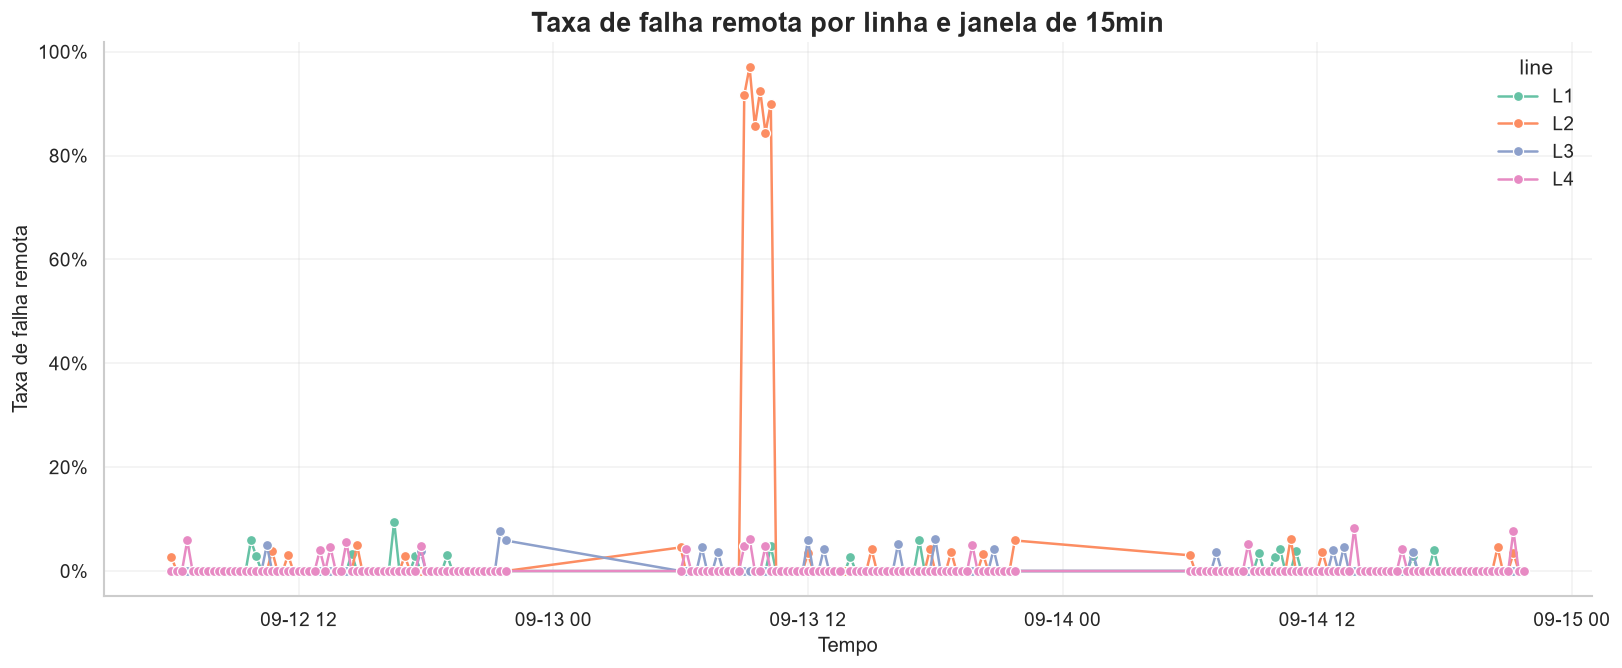

In [223]:
analysis_df["is_remote_defect"] = analysis_df["failed_step"].eq("fw_download") | analysis_df["error_code"].eq("ERR_AUTH")
remote_defects = analysis_df.loc[analysis_df["is_remote_defect"]].copy()

remote_summary = (
    analysis_df.groupby(["line", "api_key"], dropna=False)
    .agg(total_attempts=("result", "size"), remote_defects=("is_remote_defect", "sum"))
    .reset_index()
)
remote_summary["remote_defect_rate"] = remote_summary["remote_defects"] / remote_summary["total_attempts"]
display(remote_summary.sort_values("remote_defect_rate", ascending=False).head(15))

remote_time = (
    analysis_df
    .set_index("timestamp")
    .groupby(["line", "api_key", pd.Grouper(freq="15min")])
    .agg(total_attempts=("result", "size"), remote_defects=("is_remote_defect", "sum"))
    .query("total_attempts >= 10")
    .reset_index()
)
remote_time["remote_defect_rate"] = remote_time["remote_defects"] / remote_time["total_attempts"]
display(remote_time.sort_values(["remote_defect_rate", "remote_defects"], ascending=False).head(20))

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=remote_time, x="timestamp", y="remote_defect_rate", hue="line", marker="o", ax=ax)
ax.set_title("Taxa de falha remota por linha e janela de 15min")
ax.set_xlabel("Tempo")
ax.set_ylabel("Taxa de falha remota")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.show()

## Bluetooth e cabo

Aqui sao investigadas falhas de calibracao Bluetooth e problemas de cabo, especialmente `cable_channels_found == 0`.

In [224]:
bt_df = analysis_df.loc[analysis_df["has_bluetooth"]].copy()
bt_df["bt_fail"] = bt_df["bluetooth_ok"].eq(0) | bt_df["failed_step"].eq("bluetooth")
bt_summary = (
    bt_df.groupby(["line", "station", "jig_id", "model"], dropna=False)
    .agg(total_bt=("result", "size"), bt_fail=("bt_fail", "sum"))
    .reset_index()
)
bt_summary["bt_fail_rate"] = bt_summary["bt_fail"] / bt_summary["total_bt"]
print("Bluetooth - maiores taxas")
display(bt_summary.sort_values(["bt_fail_rate", "bt_fail"], ascending=False).head(15))

cable_df = analysis_df.loc[analysis_df["has_cable"]].copy()
cable_df["cable_fail"] = cable_df["cable_scan_ok"].eq(0) | cable_df["failed_step"].eq("cable_scan")
cable_df["zero_channels"] = cable_df["cable_channels_found"].eq(0)
cable_summary = (
    cable_df.groupby(["line", "station", "jig_id", "model"], dropna=False)
    .agg(
        total_cable=("result", "size"),
        cable_fail=("cable_fail", "sum"),
        zero_channels=("zero_channels", "sum"),
        avg_channels=("cable_channels_found", "mean"),
    )
    .reset_index()
)
cable_summary["cable_fail_rate"] = cable_summary["cable_fail"] / cable_summary["total_cable"]
cable_summary["zero_channels_rate"] = cable_summary["zero_channels"] / cable_summary["total_cable"]
print("Cabo - maiores taxas de 0 canais")
display(cable_summary.sort_values(["zero_channels_rate", "zero_channels"], ascending=False).head(15))

zero_channel_rows = cable_df.loc[cable_df["zero_channels"], [
    "timestamp", "line", "station", "jig_id", "model", "result", "failed_step", "error_code", "cable_channels_found", "disposition"
]].sort_values("timestamp")
print(f"Ocorrencias com 0 canais: {len(zero_channel_rows)}")
display(zero_channel_rows.head(30))

Bluetooth - maiores taxas


,line,station,jig_id,model,total_bt,bt_fail,bt_fail_rate
0,L1,L1-ST1,JIG-L1-ST1-1,STB-300,335,14,0.04
1,L1,L1-ST1,JIG-L1-ST1-1,STB-400,203,5,0.02
18,L3,L3-ST1,JIG-L3-ST1-2,STB-300,176,2,0.01
4,L1,L1-ST2,JIG-L1-ST2-1,STB-300,302,3,0.01
26,L4,L4-ST1,JIG-L4-ST1-2,STB-300,206,2,0.01
25,L4,L4-ST1,JIG-L4-ST1-1,STB-400,120,1,0.01
20,L3,L3-ST2,JIG-L3-ST2-1,STB-300,262,2,0.01
29,L4,L4-ST2,JIG-L4-ST2-1,STB-400,133,1,0.01
23,L3,L3-ST2,JIG-L3-ST2-2,STB-400,136,1,0.01
31,L4,L4-ST2,JIG-L4-ST2-2,STB-400,145,1,0.01


Cabo - maiores taxas de 0 canais


,line,station,jig_id,model,total_cable,cable_fail,zero_channels,avg_channels,cable_fail_rate,zero_channels_rate
40,L4,L4-ST1,JIG-L4-ST1-2,STB-300,206,8,8,146.15,0.04,0.04
41,L4,L4-ST1,JIG-L4-ST1-2,STB-400,130,5,5,144.12,0.04,0.04
45,L4,L4-ST2,JIG-L4-ST2-2,STB-200,268,10,10,147.26,0.04,0.04
46,L4,L4-ST2,JIG-L4-ST2-2,STB-300,196,6,6,148.11,0.03,0.03
37,L4,L4-ST1,JIG-L4-ST1-1,STB-300,224,9,6,148.50,0.04,0.03
43,L4,L4-ST2,JIG-L4-ST2-1,STB-300,213,5,5,147.68,0.02,0.02
44,L4,L4-ST2,JIG-L4-ST2-1,STB-400,133,3,3,150.59,0.02,0.02
42,L4,L4-ST2,JIG-L4-ST2-1,STB-200,247,5,5,149.56,0.02,0.02
39,L4,L4-ST1,JIG-L4-ST1-2,STB-200,261,7,5,149.80,0.03,0.02
38,L4,L4-ST1,JIG-L4-ST1-1,STB-400,120,2,2,148.41,0.02,0.02


Ocorrencias com 0 canais: 59


,timestamp,line,station,jig_id,model,result,failed_step,error_code,cable_channels_found,disposition
13828,2022-09-14 11:03:34,L4,L4-ST2,JIG-L4-ST2-2,STB-400,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13843,2022-09-14 11:05:25,L4,L4-ST2,JIG-L4-ST2-2,STB-200,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13907,2022-09-14 11:17:34,L4,L4-ST1,JIG-L4-ST1-2,STB-300,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13939,2022-09-14 11:22:10,L4,L4-ST2,JIG-L4-ST2-2,STB-200,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13961,2022-09-14 11:25:21,L4,L4-ST1,JIG-L4-ST1-2,STB-400,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13969,2022-09-14 11:26:25,L4,L4-ST2,JIG-L4-ST2-1,STB-200,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,SCRAP
13980,2022-09-14 11:27:58,L4,L4-ST1,JIG-L4-ST1-2,STB-200,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13981,2022-09-14 11:28:09,L4,L4-ST1,JIG-L4-ST1-2,STB-400,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13996,2022-09-14 11:30:51,L4,L4-ST2,JIG-L4-ST2-2,STB-300,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK
13998,2022-09-14 11:30:52,L4,L4-ST1,JIG-L4-ST1-1,STB-200,FAIL,cable_scan,ERR_NO_SIGNAL,0.00,REWORK


## Integridade: MAC e serial

O mesmo serial pode reaparecer por rework. O problema silencioso e o mesmo MAC aparecer em seriais diferentes.

In [225]:
mac_serial_counts = analysis_df.groupby("mac_address")["serial_number"].nunique().sort_values(ascending=False)
serial_mac_counts = analysis_df.groupby("serial_number")["mac_address"].nunique().sort_values(ascending=False)
serial_attempt_counts = analysis_df.groupby("serial_number")["attempt"].agg(["count", "max"])

integrity_summary = pd.DataFrame([
    ["MACs usados por mais de um serial", int(mac_serial_counts.gt(1).sum())],
    ["Seriais com mais de um MAC", int(serial_mac_counts.gt(1).sum())],
    ["Seriais com rework legitimo", int(serial_attempt_counts["max"].gt(1).sum())],
    ["Seriais com mais de 2 registros", int(serial_attempt_counts["count"].gt(2).sum())],
], columns=["check", "count"])
display(integrity_summary)

bad_macs = mac_serial_counts.loc[mac_serial_counts.gt(1)].index
bad_mac_rows = analysis_df.loc[analysis_df["mac_address"].isin(bad_macs), [
    "timestamp", "mac_address", "serial_number", "line", "station", "jig_id", "operator", "model", "result", "disposition"
]].sort_values(["mac_address", "timestamp"])
display(bad_mac_rows.head(80))

,check,count
0,MACs usados por mais de um serial,6
1,Seriais com mais de um MAC,0
2,Seriais com rework legitimo,1729
3,Seriais com mais de 2 registros,0


,timestamp,mac_address,serial_number,line,station,jig_id,operator,model,result,disposition
2575,2022-09-12 12:51:07,AC:5A:14:00:84:56,SN100220912082846,L4,L4-ST1,JIG-L4-ST1-1,OP-L4-A1,STB-100,FAIL,REWORK
3184,2022-09-12 14:24:07,AC:5A:14:00:84:56,SN100220912082846,L4,L4-ST1,JIG-L4-ST1-2,OP-L4-A2,STB-100,FAIL,SCRAP
6606,2022-09-13 07:30:44,AC:5A:14:00:84:56,SN200220913077580,L3,L3-ST2,JIG-L3-ST2-1,OP-L3-A1,STB-200,PASS,PASS
999,2022-09-12 08:46:36,AC:5A:14:65:F4:CC,SN300220912077688,L4,L4-ST2,JIG-L4-ST2-1,OP-L4-A2,STB-300,PASS,PASS
12353,2022-09-14 07:04:06,AC:5A:14:65:F4:CC,SN200220914083271,L1,L1-ST2,JIG-L1-ST2-1,OP-L1-A2,STB-200,PASS,PASS
3263,2022-09-12 14:36:42,AC:5A:14:76:EF:FF,SN100220912080687,L1,L1-ST2,JIG-L1-ST2-1,OP-L1-B2,STB-100,FAIL,REWORK
3864,2022-09-12 16:16:42,AC:5A:14:76:EF:FF,SN100220912080687,L1,L1-ST2,JIG-L1-ST2-1,OP-L1-B1,STB-100,PASS,PASS
9687,2022-09-13 15:43:03,AC:5A:14:76:EF:FF,SN400220913081827,L2,L2-ST1,JIG-L2-ST1-1,OP-L2-B1,STB-400,PASS,PASS
2919,2022-09-12 13:39:31,AC:5A:14:94:36:8E,SN200220912078445,L1,L1-ST2,JIG-L1-ST2-2,OP-L1-A2,STB-200,PASS,PASS
15949,2022-09-14 16:40:42,AC:5A:14:94:36:8E,SN100220914071148,L1,L1-ST2,JIG-L1-ST2-1,OP-L1-B1,STB-100,PASS,PASS


## Base de auditoria

No notebook, isto nao substitui a tabela filtravel do dashboard, mas ja cria a base com as colunas pedidas para filtros e a exportacao posterior.

In [226]:
audit_columns = [
    "timestamp", "date", "time", "shift", "line", "station", "jig_id", "operator",
    "model", "sku", "firmware_version", "serial_number", "mac_address", "api_key",
    "attempt", "result", "failed_step", "error_code", "disposition", "total_cycle_s",
]
audit_table = analysis_df.loc[:, audit_columns].sort_values("timestamp").copy()

print(f"Linhas na base de auditoria: {len(audit_table):,}")
display(audit_table.head(20))

# Para exportar manualmente quando necessario:
# Path('../Reports').mkdir(exist_ok=True)
# audit_table.to_csv('../Reports/audit_table.csv', index=False)

Linhas na base de auditoria: 17,844


,timestamp,date,time,shift,line,station,jig_id,operator,model,sku,firmware_version,serial_number,mac_address,api_key,attempt,result,failed_step,error_code,disposition,total_cycle_s
0,2022-09-12 06:00:06,2022-09-12,06:00:06,A,L2,L2-ST1,JIG-L2-ST1-2,OP-L2-A2,STB-300,LG-STB-300-5BC3,v4.1.2,SN300220912083468,AC:5A:14:FB:E9:2B,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,222.20
1,2022-09-12 06:00:07,2022-09-12,06:00:07,A,L1,L1-ST1,JIG-L1-ST1-1,OP-L1-A2,STB-100,LG-STB-100-2401,v4.1.2,SN100220912073344,AC:5A:14:67:01:4C,RKEY-1AA670E63C,1,PASS,NaN,NaN,PASS,157.00
2,2022-09-12 06:00:41,2022-09-12,06:00:41,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A1,STB-300,LG-STB-300-5BC3,v4.1.2,SN300220912073087,AC:5A:14:DB:76:1E,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,211.60
3,2022-09-12 06:01:00,2022-09-12,06:01:00,A,L3,L3-ST2,JIG-L3-ST2-1,OP-L3-A2,STB-200,LG-STB-200-5C02,v4.1.2,SN200220912078449,AC:5A:14:69:DD:B6,RKEY-1999061AD6,1,PASS,NaN,NaN,PASS,195.90
4,2022-09-12 06:01:14,2022-09-12,06:01:14,A,L4,L4-ST1,JIG-L4-ST1-1,OP-L4-A1,STB-400,LG-STB-400-5BC4,v4.1.2,SN400220912079140,AC:5A:14:65:6C:6D,RKEY-2742E4DF18,1,PASS,NaN,NaN,PASS,238.30
5,2022-09-12 06:01:20,2022-09-12,06:01:20,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A1,STB-100,LG-STB-100-2401,v4.1.2,SN100220912074038,AC:5A:14:8A:F2:B1,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,173.10
6,2022-09-12 06:01:27,2022-09-12,06:01:27,A,L2,L2-ST1,JIG-L2-ST1-2,OP-L2-A2,STB-300,LG-STB-300-5BC3,v4.1.2,SN300220912082662,AC:5A:14:50:F1:78,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,220.70
7,2022-09-12 06:01:40,2022-09-12,06:01:40,A,L2,L2-ST1,JIG-L2-ST1-1,OP-L2-A2,STB-100,LG-STB-100-2401,v4.1.2,SN100220912074757,AC:5A:14:F3:03:F9,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,163.60
8,2022-09-12 06:01:49,2022-09-12,06:01:49,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A2,STB-100,LG-STB-100-2401,v4.1.2,SN100220912085115,AC:5A:14:E8:54:B1,RKEY-05B595FC92,1,PASS,NaN,NaN,PASS,166.40
9,2022-09-12 06:02:20,2022-09-12,06:02:20,A,L1,L1-ST1,JIG-L1-ST1-1,OP-L1-A2,STB-200,LG-STB-200-5C02,v4.1.2,SN200220912072426,AC:5A:14:51:8C:9E,RKEY-1AA670E63C,1,PASS,NaN,NaN,PASS,208.30


## PDD integrado a analise

O PDD completo esta mantido em [`pdd-setupbox.md`](../pdd-setupbox.md). A tabela abaixo resume os elementos do documento e mostra onde cada um foi usado na EDA, criando rastreabilidade entre processo, dado e analise.

| Elemento do PDD | Definicao do processo | Evidencia/uso na EDA |
|---|---|---|
| Objetivo | Entender o processo as-is de gravacao para identificar anomalias sistemicas. | Pareto, KPIs, tendencia temporal, PPM/DPMO e analises por linha/jig/firmware. |
| Escopo | Da entrada da unidade no jig ate a classificacao final da tentativa. | Colunas `timestamp`, `line`, `station`, `jig_id`, `failed_step`, `error_code`, `attempt` e `disposition`. |
| Entradas | Modelo, SKU, serial, MAC, firmware, API key, linha, estacao, jig, operador e turno. | Quebras por `model`, `firmware_version`, `api_key`, `line`, `station`, `jig_id`, `operator` e analise de integridade MAC/serial. |
| Saidas | Resultado do teste, tempo de ciclo e disposicao final. | KPIs de yield, failure rate, FPY, rework, scrap, ciclo e tabela de auditoria. |
| RN01 - Rework | Falha na primeira tentativa gera nova tentativa para o mesmo serial. | Calculo de FPY, taxa de rework e distribuicao por `attempt`. |
| RN02 - Scrap | Falha apos rework leva a sucata. | Analise de `disposition`, ranking de defeitos associados a scrap e metricas finais. |
| RN03 - Integridade | Serial e MAC devem preservar unicidade, exceto rework do mesmo serial. | Checagem de MAC associado a multiplos seriais e serial associado a multiplos MACs. |
| RN04 - Modelos hibridos | Modelos podem ter Bluetooth, cabo, tuner e Wi-Fi diferentes. | Recortes especificos para Bluetooth, cabo/canais, tuner e etapas opcionais por modelo. |
| Eventos de parada | Downtime deve ser cruzado com quedas de qualidade. | Grafico temporal com janelas de parada e resumo de disponibilidade por linha. |
| Anomalias remotas | Falhas de API key ou download podem ocorrer em janela especifica. | Recorte de `fw_download`, `ERR_AUTH`, `api_key` e tendencia temporal. |
| Ponte para automacao | A EDA deve indicar pontos monitoraveis para dashboard/alertas. | Base de auditoria e lista de anomalias priorizadas para compor o dashboard. |
